# Predicción de abandono de clientes (Customer Churn)

Proyecto de Machine Learning para predecir el abandono de clientes en una empresa del sector telecomunicaciones.

**Autor:** Luis Pastor Nuevo
**Tecnologías utilizadas:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn  
**Tipo de proyecto:** Análisis predictivo aplicado a negocio

## 1. Problema de negocio

El abandono de clientes (churn) es uno de los principales retos en el sector de las telecomunicaciones. 
Captar nuevos clientes suele ser significativamente más costoso que retener a los clientes actuales.

En este contexto, disponer de modelos predictivos capaces de identificar clientes con alta probabilidad de abandono permite a las empresas implementar estrategias de retención de forma anticipada.

Este proyecto tiene como objetivo desarrollar un modelo de Machine Learning que permita predecir qué clientes presentan mayor riesgo de abandono.

## 2. Objetivos del proyecto

Los principales objetivos de este proyecto son:

- Identificar los factores que influyen en el abandono de clientes.
- Construir un modelo predictivo capaz de estimar la probabilidad de `churn`.
- Evaluar el rendimiento del modelo utilizando métricas adecuadas.
- Extraer conclusiones que puedan apoyar estrategias de retención de clientes.

In [1]:
# ==============================
# Librerías estándar
# ==============================
import warnings

# ==============================
# Manipulación de datos
# ==============================
import pandas as pd
import numpy as np

# ==============================
# Visualización
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Configuración
# ==============================

RANDOM_STATE = 42

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%config InlineBackend.figure_format = 'retina'

## 3. Descripción del dataset

El conjunto de datos utilizado contiene información sobre clientes de una empresa de telecomunicaciones.

Incluye variables relacionadas con:

- características demográficas del cliente
- tipo de servicios contratados
- condiciones del contrato
- comportamiento de pago
- historial de permanencia

La variable objetivo del modelo es **churn**, que indica si el cliente ha abandonado o no el servicio.

## Fuente de datos

EL conjunto de datos público `WA_Fn-UseC_-Telco-Customer-Churn.csv`, relativo al abandono en una operadora de telecomunicaciones, ha sido obtenido en el sitio de [IBM analytics](https://www.ibm.com/docs/en/cognos-analytics/11.2.x?topic=samples-telco-customer-churn). También está disponible en Kaggle.

Este tipo de dataset es ampliamente utilizado en proyectos de analítica predictiva para modelar el abandono de clientes.

In [2]:
# ==============================
# Carga del dataset
# ==============================

df_raw = pd.read_csv(
    "data/churn/WA_Fn-UseC_-Telco-Customer-Churn.csv",
    index_col=0
)

# ==============================
# Información básica del dataset
# ==============================

n_rows, n_cols = df_raw.shape

print(f"Número de registros: {n_rows}")
print(f"Número de variables: {n_cols}")

if df_raw.index.is_unique:
    print("El índice del dataset es único.")
else:
    print("Advertencia: el índice contiene valores duplicados.")

print("\nInformación del dataset:")
df_raw.info()

# ==============================
# Vista preliminar
# ==============================

df_raw.head()

Número de registros: 7043
Número de variables: 20
El índice del dataset es único.

Información del dataset:
<class 'pandas.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-nu

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Análisis exploratorio de datos (EDA)

Antes de construir el modelo predictivo se realizó un análisis exploratorio de los datos con el objetivo de:

- Comprender la distribución de las variables.
- Identificar posibles valores atípicos.
- Analizar la relación entre las variables explicativas y el abandono de clientes.
- Evaluar el posible desbalanceo entre clases.

Este análisis permite obtener una primera visión del comportamiento de los datos y orientar las etapas posteriores de modelado.

In [3]:
# Se crea una copia para no tocar el dataframe original
df = df_raw.copy()

### 4.1 Distribución de la variable objetivo

Uno de los aspectos clave en problemas de clasificación es analizar la distribución de la variable objetivo.

En este caso, se estudia la variable **churn**, que indica si un cliente ha abandonado el servicio.

Este análisis permite:

- Identificar posibles desbalances entre clases. 
- Anticipar dificultades en el entrenamiento del modelo.  
- Seleccionar métricas de evaluación adecuadas. 

A continuación, se muestra la distribución de clientes que permanecen en la compañía frente a aquellos que abandonan el servicio.

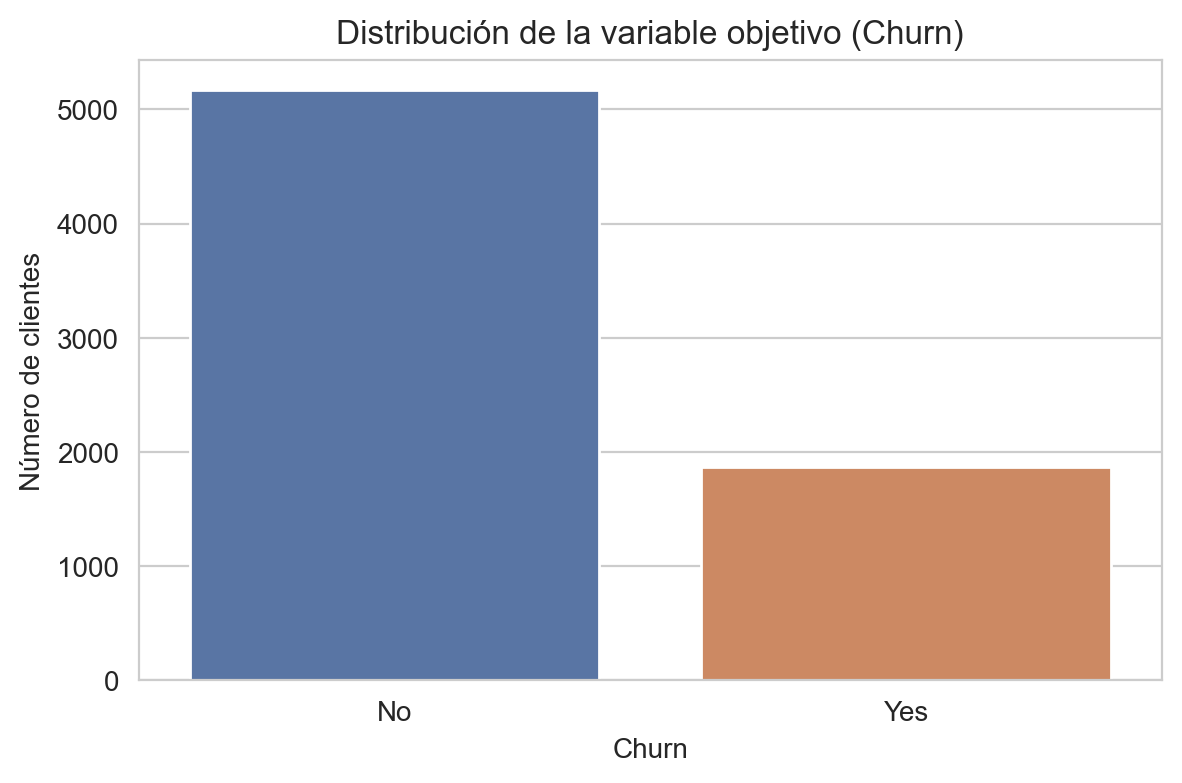

Clases presentes: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Tasa de churn: 26.54%


In [4]:
# ==============================
# Distribución de la variable objetivo
# ==============================

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="Churn",
    order=["No", "Yes"],
    palette={"No": "#4C72B0", "Yes": "#DD8452"}
)
plt.title("Distribución de la variable objetivo (Churn)")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

# ==============================
# Estadísticas básicas
# ==============================

classes = df["Churn"].unique()
churn_rate = (df["Churn"] == "Yes").mean()

print(f"Clases presentes: {classes}")
print(f"Tasa de churn: {churn_rate:.2%}")

### Insight

La distribución de la variable objetivo muestra un desbalance moderado entre clases:

- Clientes que permanecen: aproximadamente 73 %
- Clientes que abandonan: aproximadamente 27 %

Este desbalance puede afectar al rendimiento del modelo, ya que podría favorecer la clase mayoritaria.

Por este motivo, no es recomendable evaluar el modelo únicamente con la métrica de accuracy, siendo más apropiado utilizar métricas como precision, recall o ROC-AUC.

### 4.2 Variables categóricas vs Churn 

Antes de aplicar técnicas de codificación, es importante distinguir entre variables categóricas binarias y multiclase, ya que pueden requerir tratamientos diferentes dentro del pipeline de Machine Learning.

Para estructurar el flujo de transformación de datos de forma reproducible, se definen los elementos necesarios para la construcción del pipeline de preprocesamiento.

Por un lado, se registran las transformaciones que se aplicarán secuencialmente sobre el dataset.  
Por otro, se identifican las variables según su tipo, lo que permitirá aplicar tratamientos diferenciados dentro del pipeline de Machine Learning.

En particular, se definen:

- `churn_data_prep_pipeline`: lista de transformaciones aplicadas al dataset durante la fase de preprocesamiento.

- `cat_features`: conjunto de variables categóricas que requieren codificación específica.

- `num_features`: conjunto de variables numéricas que serán tratadas mediante técnicas de escalado o normalización.

Esta organización permite construir un pipeline modular, reproducible y fácilmente extensible.

Este enfoque evita inconsistencias entre entrenamiento e inferencia y facilita su integración en entornos de producción.

In [5]:
# =================================================
# Inicialización de estructuras de preprocesamiento
# =================================================

from typing import List

cat_features: List[str] = []
num_features: List[str] = []

In [6]:
# ==============================
# Codificación de la variable objetivo
# ==============================
# Convertimos la variable Churn a binaria: 1 = cliente que abandona, 0 = cliente que permanece
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Resumen de la variable objetivo
churn_rate = df['Churn'].mean()
print(f"Tasa de churn: {churn_rate:.2%}")

Tasa de churn: 26.54%


Una vez explorada la clase, se procede con las características, para lo cual se comprobarán primero los tipos.

In [7]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                 int64
dtype: object

### 4.3 Identificación de variables.

Antes de aplicar técnicas de codificación, es importante distinguir entre variables categóricas binarias y multiclase, ya que pueden requerir tratamientos diferentes dentro del pipeline de Machine Learning.

In [8]:
# ==============================
# Identificación de variables
# ==============================

# Columnas discretas (no numéricas)
dis_df_columns = df.select_dtypes(exclude=np.number).columns

# Columnas numéricas
num_df_columns = df.select_dtypes(include=np.number).columns

# Número de valores únicos por columna discreta
num_values_dis_df_col = [(col, df[col].nunique()) for col in dis_df_columns]

# Variables binarias (solo 2 valores)
binary_cat_features = [col for col, n in num_values_dis_df_col if n == 2]

# Variables categóricas multiclase (3-4 valores)
multi_cat_features = [col for col, n in num_values_dis_df_col if 2 < n < 5]

# Variables categóricas para pipeline (excluyendo Contract, que es ordinal)
cat_features = multi_cat_features.copy()
if 'Contract' in cat_features:
    cat_features.remove('Contract')

# Variables numéricas para pipeline
num_features = list(num_df_columns) + binary_cat_features

# Imprimir resumen
print("Variables binarias:", binary_cat_features)
print("Variables multiclase:", multi_cat_features)
print("Variables categóricas finales para pipeline:", cat_features)
print("Variables numéricas finales para pipeline:", num_features)

Variables binarias: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Variables multiclase: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Variables categóricas finales para pipeline: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']
Variables numéricas finales para pipeline: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


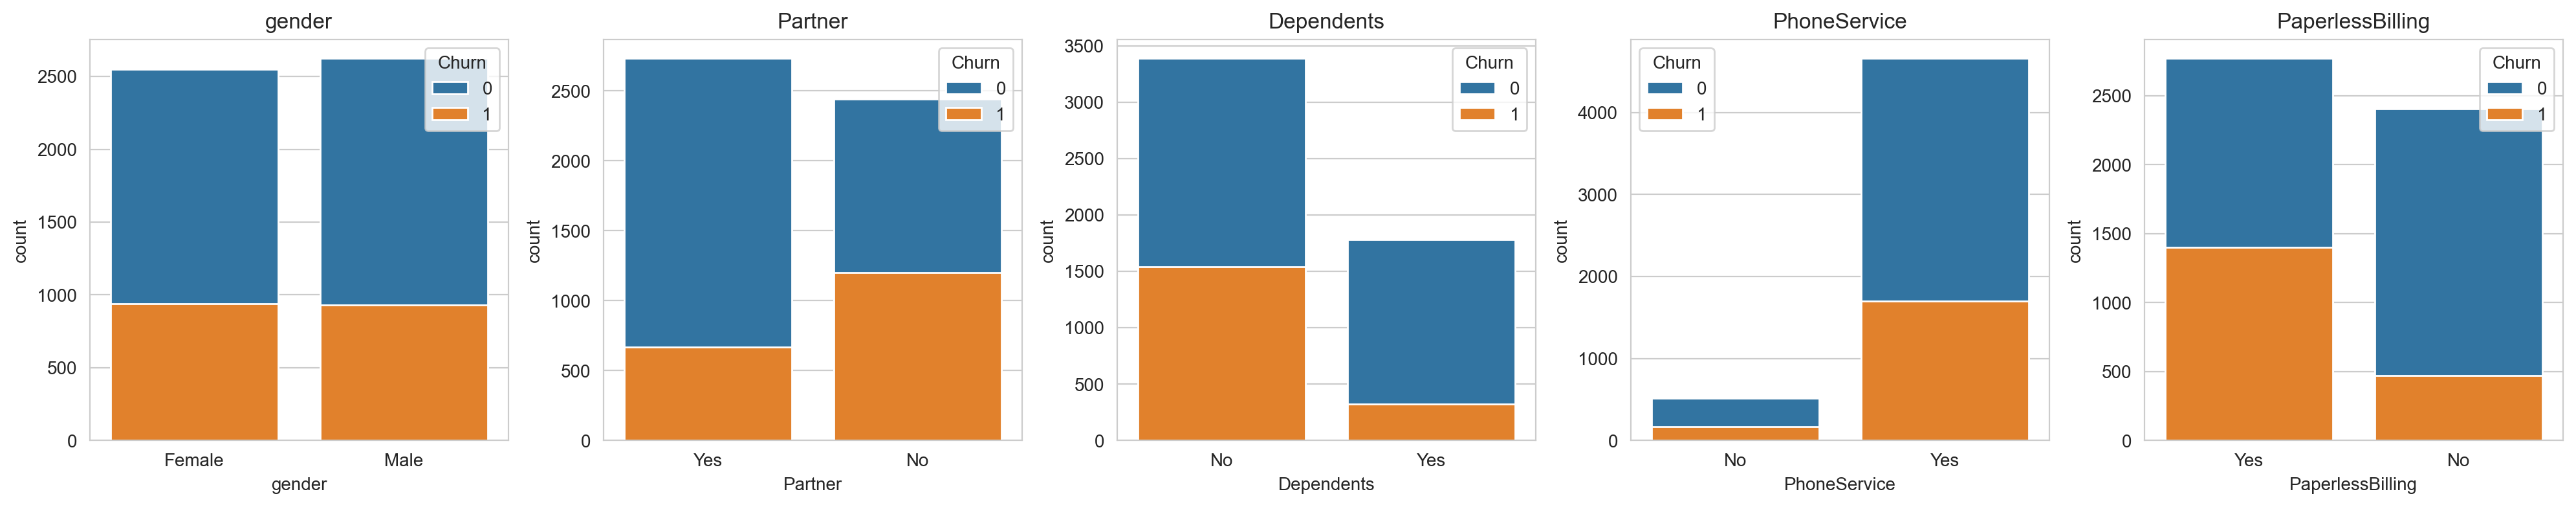

In [9]:
fig, axes = plt.subplots(1, len(binary_cat_features), figsize=(4 * len(binary_cat_features), 4))

for ax, col in zip(axes, binary_cat_features):
    sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        dodge=False,
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

Se observa que algunas variables binarias presentan diferencias claras en la proporción de churn, lo que sugiere que podrían tener capacidad predictiva.

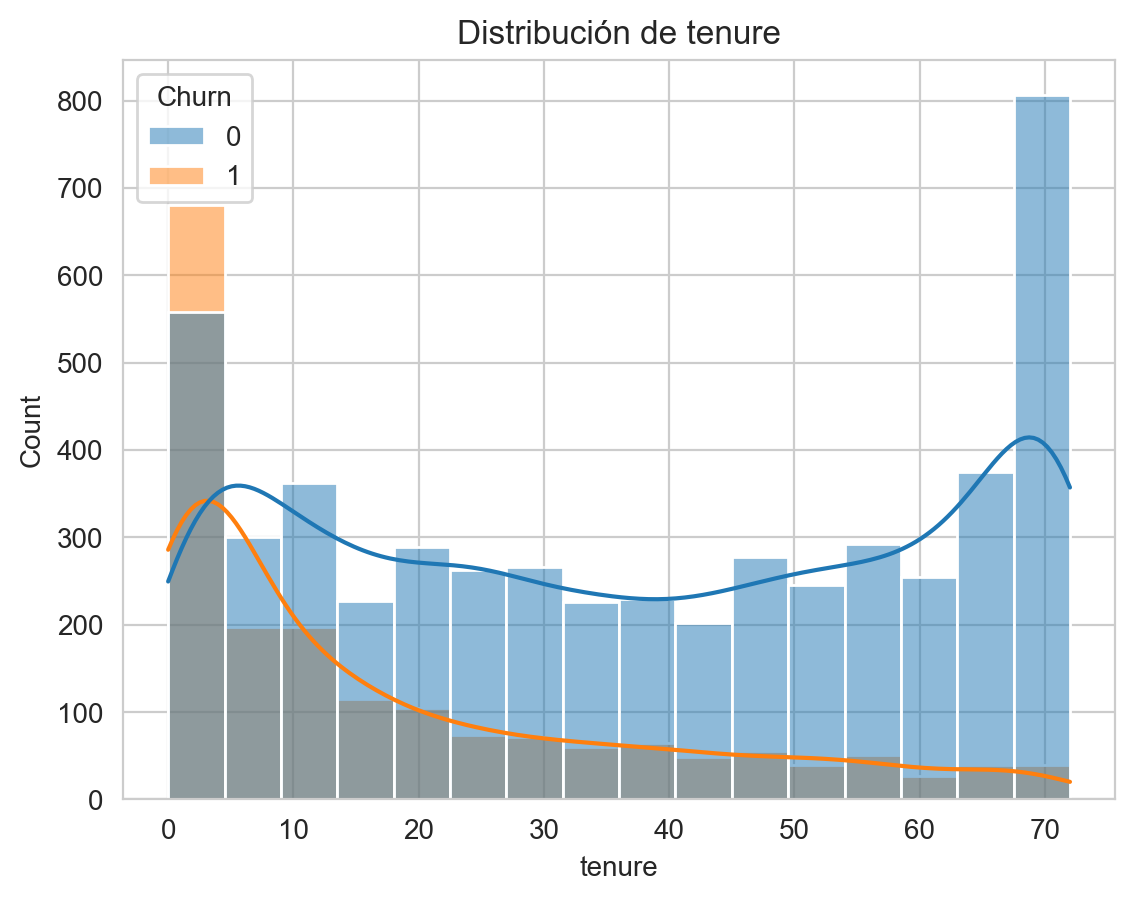

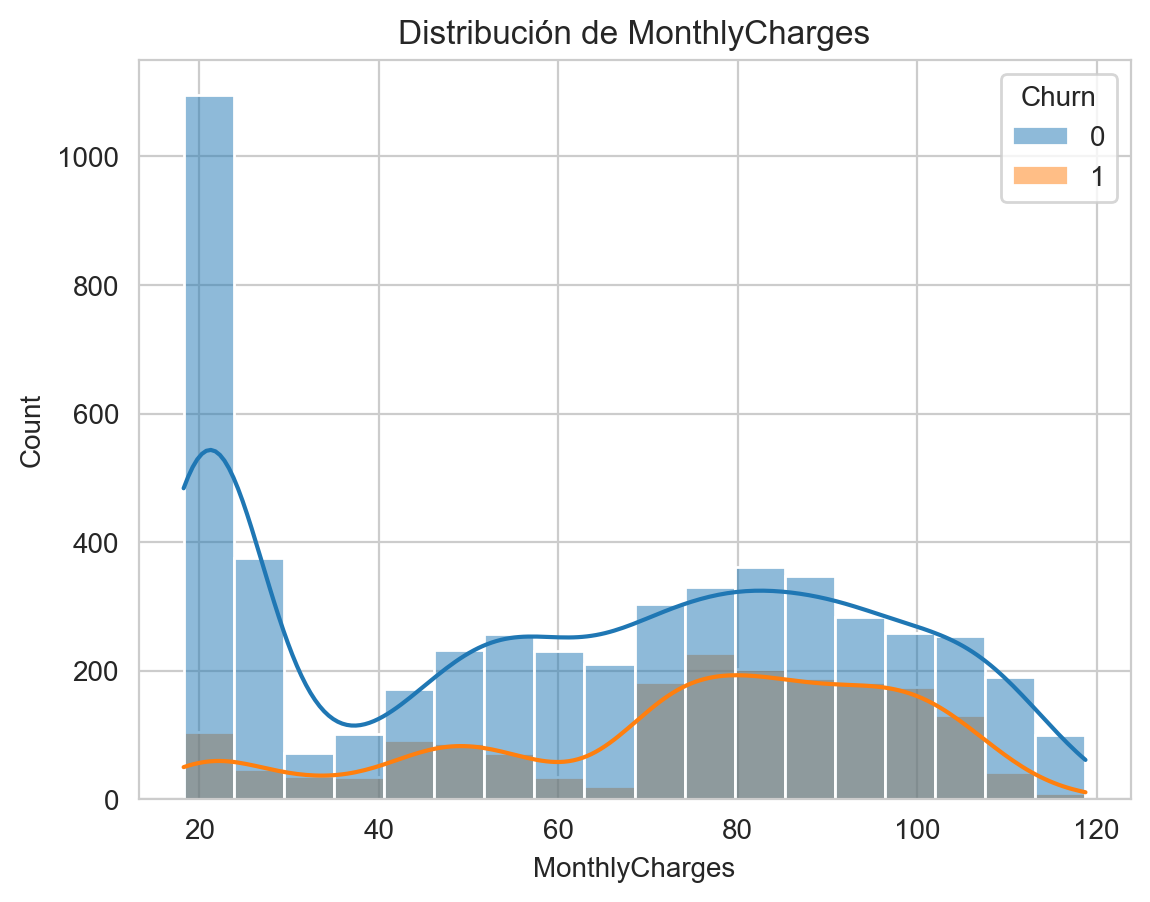

In [10]:
for col in ['tenure', 'MonthlyCharges']:
    sns.histplot(data=df, x=col, hue='Churn', kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

### 4.4 Variables categóricas de baja cardinalidad.

In [11]:
# ==============================
# Análisis de cardinalidad de variables categóricas
# ==============================

# Número de valores únicos por variable categórica
cat_unique_counts = {
    col: df[col].nunique()
    for col in cat_features
}

# Variables categóricas con baja cardinalidad (3-4 categorías)
low_cardinality_features = [
    col for col in cat_features
    if 2 < df[col].nunique() < 5
]

print(f"Variables categóricas de baja cardinalidad ({len(low_cardinality_features)}):")
print(low_cardinality_features)

Variables categóricas de baja cardinalidad (9):
['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']


Las variables categóricas con baja cardinalidad (entre 3 y 4 categorías) son candidatas adecuadas para técnicas de codificación como One-Hot Encoding, ya que no incrementan significativamente la dimensionalidad del dataset.

En etapas posteriores, se evaluará si alguna de estas variables puede tratarse como ordinal en función de su naturaleza.

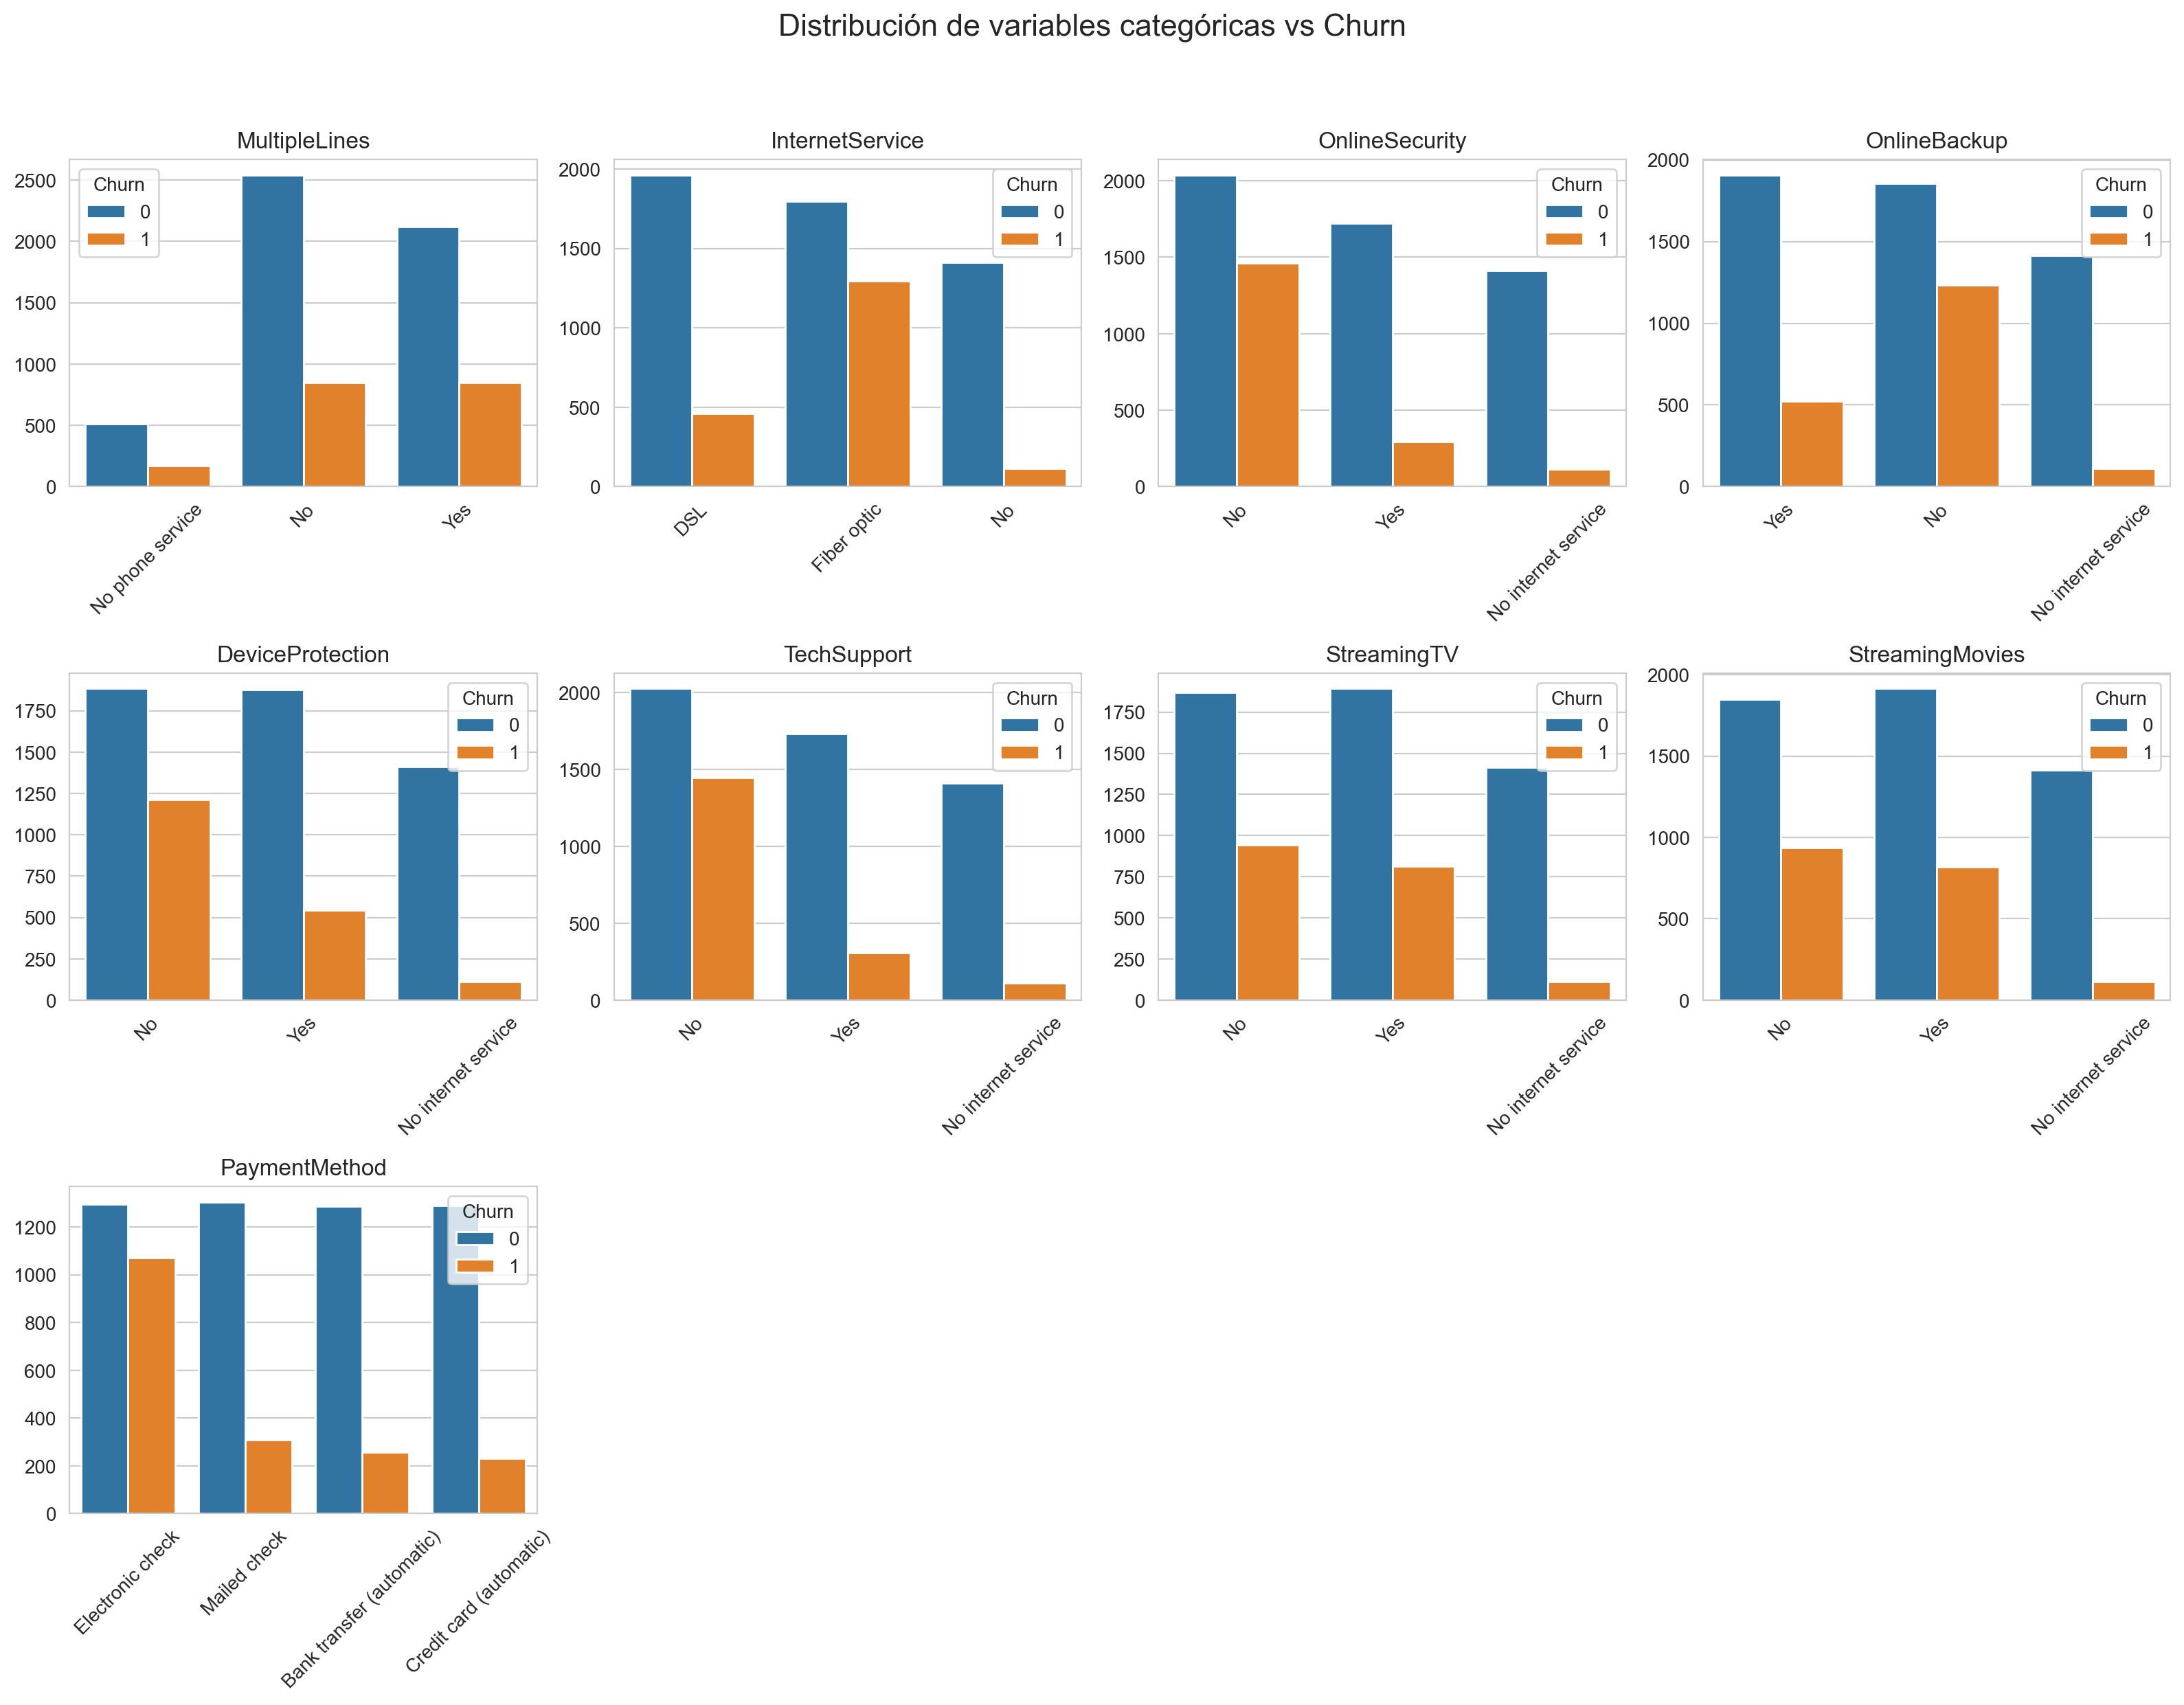

In [12]:
# ==============================
# Distribución de variables categóricas
# ==============================

# Número de columnas por fila (ajustable)
n_cols = 4
n_rows = int(np.ceil(len(low_cardinality_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

fig.suptitle(
    "Distribución de variables categóricas vs Churn",
    fontsize=16,
    y=1.03
)

# Asegurar que axes sea iterable
axes = axes.flatten()

for ax, col in zip(axes, low_cardinality_features):
    sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        ax=ax
    )
    
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=45)

# Eliminar subplots vacíos si los hay
for ax in axes[len(low_cardinality_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

### 4.5 Análisis individual de variables relevantes.

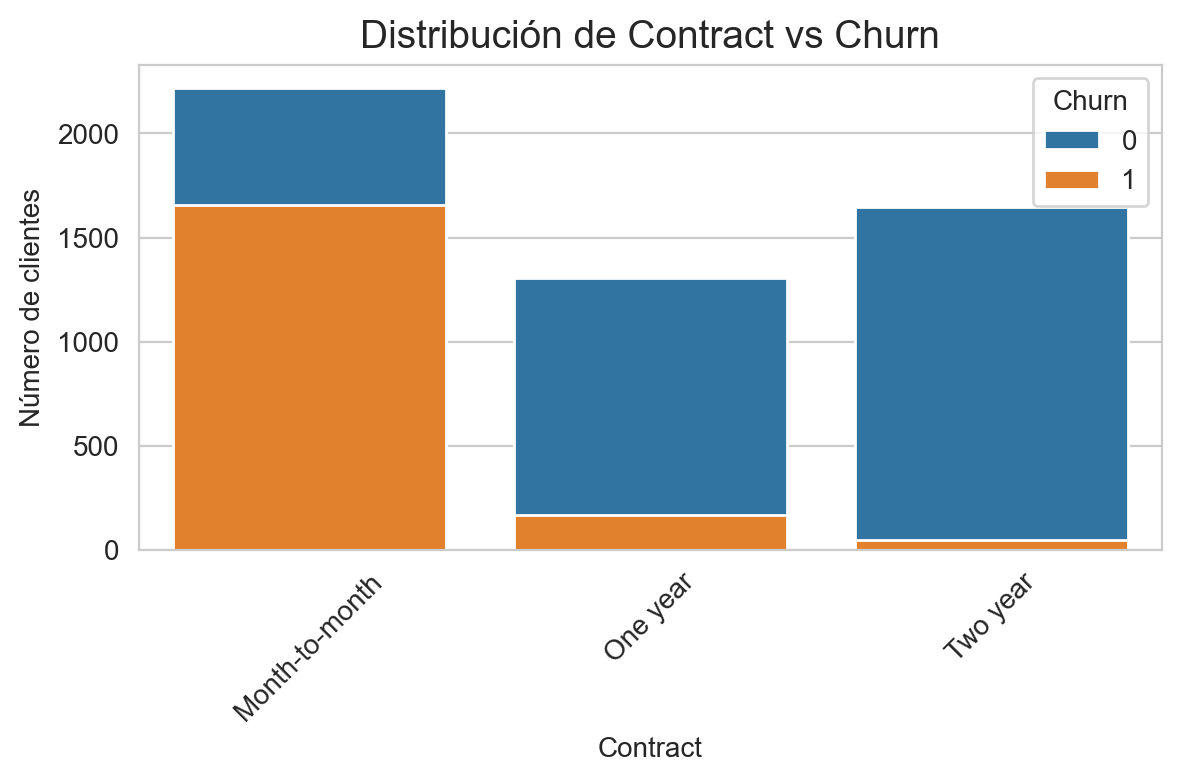

In [13]:
# ==============================
# Análisis de la variable Contract vs Churn
# ==============================

col_name = 'Contract'

plt.figure(figsize=(6, 4))

order = ['Month-to-month', 'One year', 'Two year']

sns.countplot(
    data=df,
    x=col_name,
    hue='Churn',
    order=order,
    dodge=False
)

plt.title(f"Distribución de {col_name} vs Churn", fontsize=14)
plt.xlabel(col_name)
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Se observa que los clientes con contratos mensuales presentan una proporción significativamente mayor de abandono en comparación con aquellos con contratos de mayor duración.

En particular, los contratos de tipo Month-to-month concentran la mayor parte de los casos de churn, lo que sugiere una menor fidelización en este segmento de clientes.

Este patrón indica que el tipo de contrato es una variable altamente relevante para la predicción del abandono.

<Axes: xlabel='Contract', ylabel='Count'>

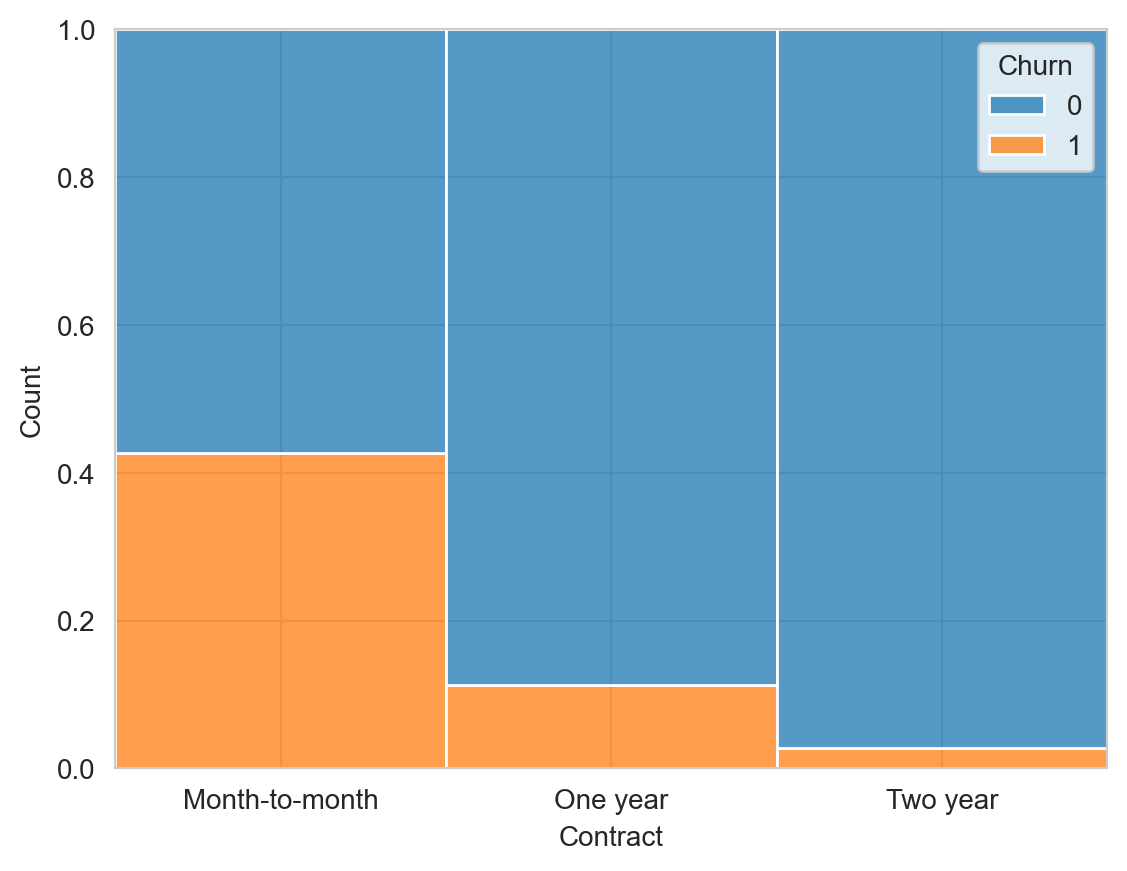

In [14]:
sns.histplot(
    data=df,
    x=col_name,
    hue='Churn',
    multiple='fill'
)

### 4.6 Análisis de variables numéricas

El análisis de variables numéricas tiene como objetivo validar la consistencia de los datos y detectar posibles problemas que puedan afectar al rendimiento de los modelos.

En particular, se analizan los siguientes aspectos:

- Tipo de las variables.
- Presencia de valores atípicos.
- Existencia de valores perdidos.
- Distribución de las variables.

#### Comprobación de tipos

Aunque una variable esté almacenada como numérica, puede representar en realidad una categoría (por ejemplo, variables binarias).

Para detectar estos casos, se analiza el número de valores únicos que toma cada variable.

In [15]:
# ==============================
# Número de valores únicos por variable numérica
# ==============================

for col in num_df_columns:
    print(f"{col}: {df[col].nunique()}")

SeniorCitizen: 2
tenure: 73
MonthlyCharges: 1585
Churn: 2


#### Insight

Se observa que:

- seniorCitizen y churn son variables binarias.
- tenure y monthlyCharges son variables numéricas continuas.

Por tanto, no es necesario realizar cambios en esta fase.

#### Detección de outliers

Se analizan las estadísticas descriptivas para identificar posibles valores atípicos en las variables numéricas.

La variable TotalCharges está almacenada como str, aunque representa una magnitud numérica.

In [16]:
# Conversión SOLO para análisis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [17]:
# ==============================
# Estadísticas descriptivas
# ==============================

df[num_df_columns.to_list() + ['TotalCharges']].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
)

,SeniorCitizen,tenure,MonthlyCharges,Churn,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,0.265370,2283.300441
std,0.368612,24.559481,30.090047,0.441561,2266.771362
min,0.000000,0.000000,18.250000,0.000000,18.800000
1%,0.000000,1.000000,19.200000,0.000000,19.900000
25%,0.000000,9.000000,35.500000,0.000000,401.450000
50%,0.000000,29.000000,70.350000,0.000000,1397.475000
75%,0.000000,55.000000,89.850000,1.000000,3794.737500
99%,1.000000,72.000000,114.729000,1.000000,8039.883000
max,1.000000,72.000000,118.750000,1.000000,8684.800000


#### Insight

Los valores mínimo y máximo en las variables tenure, MonthlyCharges y TotalCharges se encuentran dentro de rangos razonables.

No se identifican outliers significativos que requieran tratamiento en esta fase.

#### Detección de valores perdidos

Se analiza la presencia de valores nulos en las variables numéricas.

In [18]:
# ==============================
# Detección de valores perdidos
# ==============================

df[num_df_columns.to_list() + ['TotalCharges']].isna().any()

SeniorCitizen     False
tenure            False
MonthlyCharges    False
Churn             False
TotalCharges       True
dtype: bool

Se observa que únicamente la variable TotalCharges presenta valores perdidos.

In [19]:
# Ver NaN en TotalCharges
print("Número de NaN:", df['TotalCharges'].isna().sum())

Número de NaN: 11


El tratamiento de valores perdidos se realizará posteriormente dentro del pipeline de preprocesamiento.

Este enfoque permite calcular estadísticas (como la media o mediana) únicamente sobre el conjunto de entrenamiento, evitando problemas de data leakage.

### 4.7 Análisis de variables numéricas respecto a la variable objetivo

Con el objetivo de analizar la relación entre las variables numéricas y la variable objetivo (`Churn`), se representan las distribuciones de las variables continuas diferenciando por clase.

En particular, se analizan las siguientes variables:

- `tenure`: número de meses que el cliente ha permanecido en el servicio  
- `MonthlyCharges`: coste mensual del servicio  
- `TotalCharges`: gasto total acumulado  

Para cada variable se representa una estimación de densidad (`KDE`), diferenciando entre clientes que han abandonado el servicio y los que no.

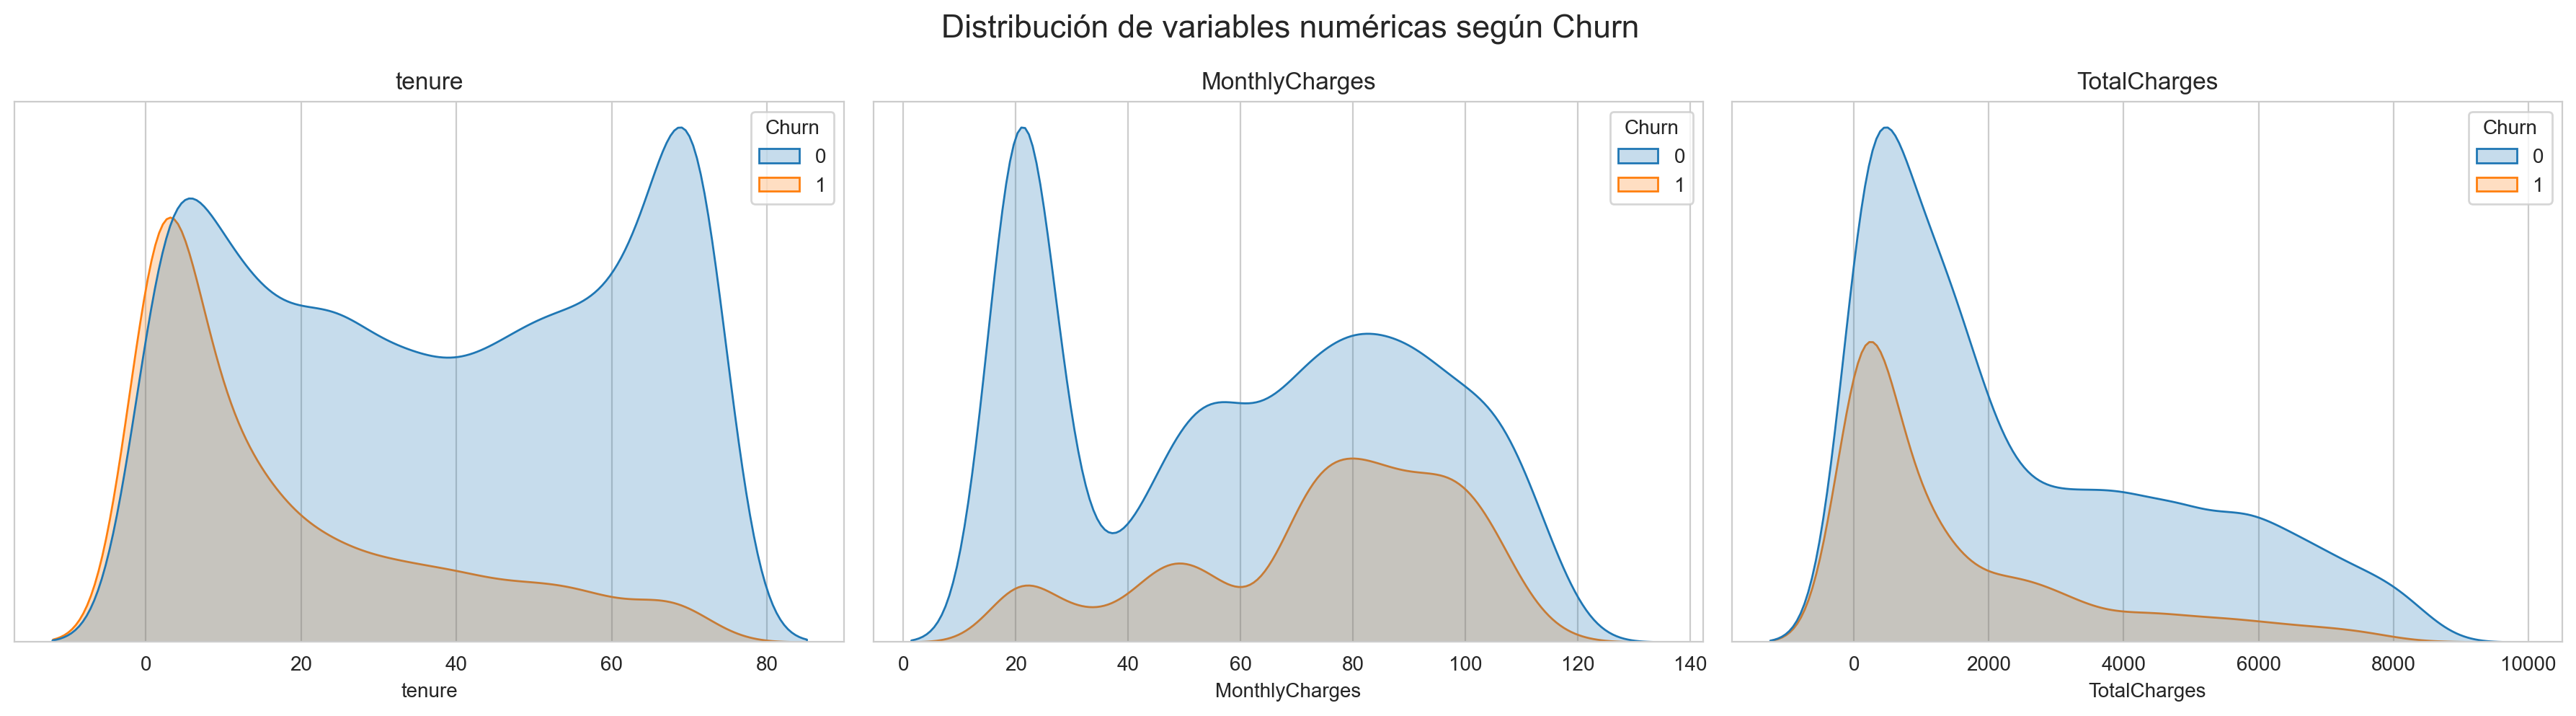

In [20]:
# ==============================
# Distribución de variables numéricas por clase
# ==============================

features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# En caso de valores perdidos
df_plot = df.dropna()

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axs, features):
    
    sns.kdeplot(
        data=df_plot,
        x=col,
        hue='Churn',
        fill=True,
        ax=ax
    )
    
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("")
    ax.set_yticks([])

fig.suptitle("Distribución de variables numéricas según Churn", fontsize=16)
plt.tight_layout()

plt.show()

#### Interpretación de resultados

A partir de las distribuciones representadas, se pueden extraer las siguientes conclusiones:

- **tenure**:  
  Es la variable más discriminante. Se observa que los clientes con menor antigüedad presentan una probabilidad significativamente mayor de abandonar el servicio. En particular, existe una alta concentración de bajas durante los primeros meses. Por el contrario, los clientes con mayor permanencia (superior a 24-36 meses) muestran una tasa de abandono muy reducida.

- **MonthlyCharges**:  
  Se observa que los clientes con cuotas mensuales bajas presentan una menor tasa de abandono. A partir de cierto umbral (aproximadamente 25 unidades monetarias), la probabilidad de churn se estabiliza y no muestra grandes variaciones.

- **TotalCharges**:  
  No se aprecia una separación clara entre las distribuciones de ambas clases. Esto sugiere que esta variable, por sí sola, tiene menor capacidad explicativa en relación con la variable objetivo.

En conjunto, `tenure` emerge como la variable numérica más relevante para la predicción del churn.

### 4.8 Análisis de correlación entre variables numéricas

Con el objetivo de identificar relaciones lineales entre las variables numéricas, se calcula la matriz de correlación de Pearson.

Este análisis permite:

- Detectar dependencias entre variables.  
- Identificar posibles problemas de multicolinealidad.  
- Evaluar la relación de las variables con la variable objetivo (`Churn`).  

La matriz de correlación se representa mediante un mapa de calor para facilitar su interpretación visual.

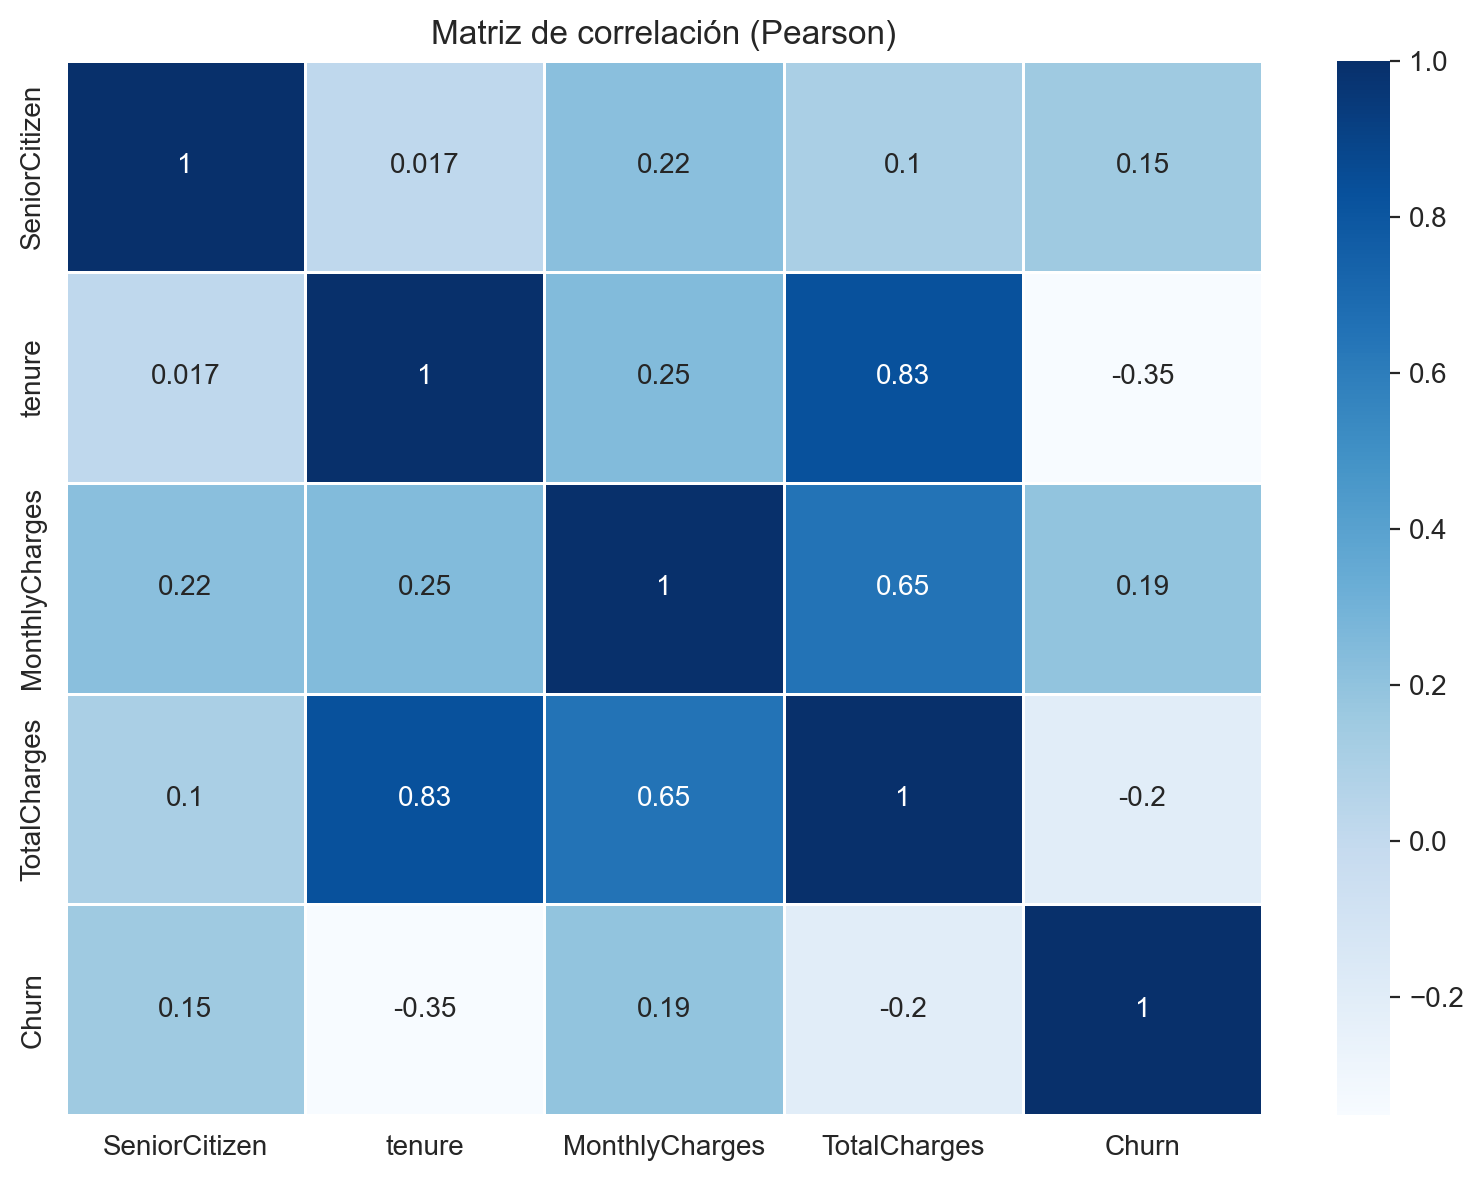

In [21]:
# ==============================
# Matriz de correlación
# ==============================

corrmat = df.select_dtypes(include=np.number).corr(method='pearson')

plt.figure(figsize=(8, 6))

sns.heatmap(
    corrmat,
    cmap="Blues",
    linewidths=0.5,
    annot = True
)

plt.title("Matriz de correlación (Pearson)", fontsize=12)

plt.tight_layout()
plt.show()

In [22]:
corrmat['Churn'].sort_values(ascending=False)

Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn, dtype: float64

#### Interpretación de resultados

A partir del mapa de calor se pueden extraer las siguientes conclusiones:

- **Correlación entre variables numéricas**:  
  Se observa una alta correlación entre `tenure`, `MonthlyCharges` y `TotalCharges`, lo cual es coherente dado que el gasto total depende directamente del tiempo de permanencia y del coste mensual.

- **Relación con la variable objetivo (`Churn`)**:  
  La variable `Churn` presenta correlación negativa con `tenure` y `Contract`. Esto indica que los clientes con mayor antigüedad o con contratos de mayor duración tienen menor probabilidad de abandonar el servicio.

- **Relaciones entre variables categóricas transformadas**:  
  Se observa correlación entre variables como `Partner` y `Dependents`, lo cual sugiere que ambas capturan información similar sobre el entorno del cliente.

- **Implicaciones para el modelado**:  
  La presencia de variables altamente correlacionadas puede generar redundancia en el modelo. En algunos casos, podría ser conveniente eliminar o transformar estas variables para reducir la multicolinealidad, especialmente en modelos sensibles a este fenómeno (como regresión logística).

En conjunto, este análisis permite identificar relaciones relevantes entre variables y orientar decisiones posteriores en el proceso de modelado.

## 5. Preparación de datos

Antes del entrenamiento de los modelos se realizaron diferentes tareas de preparación de datos:

- Tratamiento de valores faltantes.
- Transformación de variables categóricas.
- Escalado de variables numéricas.
- Separación entre variables predictoras y variable objetivo.

Estas transformaciones permiten que los modelos de Machine Learning puedan trabajar correctamente con los datos.

In [23]:
# Copia del dataset original para preprocesamiento
df_churn = df_raw.copy()

df_churn['Churn'] = df_churn['Churn'].map({'Yes': 1, 'No': 0})

### 5.1 Tratamiento de variables categóricas y ordinales

Las variables categóricas del dataset presentan diferentes características en función de su número de categorías y su naturaleza.

Por un lado, la mayoría de las variables categóricas no presentan un orden intrínseco y serán posteriormente transformadas mediante técnicas de codificación como One-Hot Encoding.

Por otro lado, la variable **Contract** sí presenta una relación ordinal natural entre sus categorías, ya que refleja el nivel de compromiso del cliente con la compañía:

- Month-to-month → menor compromiso.

- One year → compromiso intermedio.

- Two year → mayor compromiso.

Por este motivo, se decide tratar esta variable como ordinal, transformándola en valores numéricos que preservan dicha relación.

Transformación de la variable ordinal **Contract**

Para preservar la relación de orden entre las categorías de la variable **Contract**, se realiza una transformación a valores numéricos utilizando un mapeo explícito.

Este enfoque permite que los modelos de Machine Learning puedan capturar la progresión en el nivel de compromiso del cliente.

In [24]:
# ==============================
# Transformación ordinal de Contract
# ==============================

con_to_ordinal = {
    'Month-to-month': 1,
    'One year': 2,
    'Two year': 3
}

def churn_transform_contract(df):
    df['Contract'] = df['Contract'].map(con_to_ordinal)
    return df

Se evita One-Hot Encoding en Contract para no perder la información ordinal y evitar aumentar la dimensionalidad innecesariamente

### 5.2 Integración de transformaciones en el pipeline

Una vez definida la transformación de la variable Contract, se integra dentro del flujo de preprocesamiento.

Este enfoque permite:

- Garantizar consistencia entre entrenamiento e inferencia.
- Estructurar el preprocesamiento de forma modular.
- Facilitar la reutilización del modelo en entornos de producción.

Dado que Contract ha sido transformada a una variable numérica ordinal, se incorpora al conjunto de variables numéricas del modelo.

In [25]:
# ==============================
# Actualización de variables numéricas
# ==============================

# Añadir 'Contract' como variable numérica
if 'Contract' not in num_features:
    num_features.append('Contract')

print("Variables numéricas actualizadas:")
print(num_features)

Variables numéricas actualizadas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Contract']


### 5.3 Transformación de variables numéricas y consolidación del pipeline

#### Conversión de variables numéricas almacenadas como texto.

La variable TotalCharges, aunque conceptualmente es numérica, se encuentra almacenada como tipo object. Esto suele ocurrir cuando existen valores no válidos o inconsistencias en los datos de origen.

Para resolverlo, se convierte la variable a formato numérico, asignando valores NaN a aquellas observaciones que no pueden ser transformadas correctamente.

Este tratamiento permite:

- Asegurar la consistencia de tipos de datos.
- Facilitar el uso de algoritmos de Machine Learning.
- Identificar posibles valores faltantes derivados del proceso.

In [26]:
# ==============================
# Conversión de TotalCharges a numérico
# ==============================

# Añadir 'TotalCharges' como variable numérica
if 'TotalCharges' not in num_features:
    num_features.append('TotalCharges')

def churn_charges_to_numeric(df):
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    return df

In [27]:
# Validación sobre una muestra
display(churn_charges_to_numeric(df_churn.head(5).copy()))

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


#### Actualización de variables numéricas

Una vez transformada, la variable TotalCharges pasa a formar parte del conjunto de variables numéricas utilizadas por el modelo.

Estas incluyen:

- variables originalmente numéricas.
- variables transformadas durante el preprocesamiento.

In [28]:
churn_data_prep_pipeline = [
    churn_transform_contract,
    churn_charges_to_numeric
]

In [29]:
# ==============================
# Resumen del pipeline
# ==============================

print("\nPasos de preprocesamiento:")
for step, function in enumerate(churn_data_prep_pipeline):
    print(f"\t{step}: {function.__name__}")


Pasos de preprocesamiento:
	0: churn_transform_contract
	1: churn_charges_to_numeric


#### Resumen del preprocesamiento

Hasta este punto, se han definido e integrado las principales transformaciones necesarias para preparar los datos:

- transformación ordinal de variables con orden inherente.
- conversión de variables numéricas almacenadas como texto.

Todas estas transformaciones se han estructurado en un pipeline para asegurar su correcta aplicación en todo el flujo de modelado.

#### Tratamiento de variables categóricas binarias

En este proyecto no se realiza una binarización manual de las variables categóricas binarias. En su lugar, se opta por un enfoque unificado basado en técnicas de codificación como `One-Hot Encoding`, que permite tratar de forma homogénea todas las variables categóricas.

Este enfoque simplifica el pipeline de preprocesamiento y mejora su escalabilidad.

In [30]:
# ==============================
# Resumen de variables
# ==============================

print("Variables categóricas:\n\t", cat_features, end="\n\n")
print("Variables numéricas:\n\t", num_features)

Variables categóricas:
	 ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']

Variables numéricas:
	 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Contract', 'TotalCharges']


### 5.4 Aplicación del pipeline de preprocesamiento

Con el objetivo de estructurar y automatizar el proceso de transformación de los datos, se define una función que aplica de forma secuencial todas las transformaciones incluidas en el pipeline de preprocesamiento.

Este enfoque permite:

- Garantizar la consistencia en la transformación de datos.  
- Facilitar la reutilización del código.
- Aplicar el mismo preprocesamiento tanto en entrenamiento como en inferencia.  

Cada función del pipeline se aplica de manera iterativa sobre el *DataFrame* de entrada.

In [31]:
# ==============================
# Función de aplicación del pipeline
# ==============================

def preprocess_data(df, churn_data_prep_pipeline):
    """
    Aplica secuencialmente las funciones de preprocesamiento
    sobre un DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame de entrada
    churn_data_prep_pipeline : list
        Lista de funciones de preprocesamiento

    Returns
    -------
    pandas.DataFrame
        DataFrame transformado
    """
    
    df = df.copy()  # evitar modificar el original
    
    for function in churn_data_prep_pipeline:
        df = function(df)
        
    return df

Aunque podría utilizarse el método `DataFrame.pipe()` para encadenar transformaciones, en este caso se opta por una implementación explícita mediante una lista de funciones, lo que facilita la comprensión y el control del flujo de preprocesamiento.

In [32]:
# ==============================
# Validación del pipeline
# ==============================

preprocess_data(df_churn, churn_data_prep_pipeline)

# Se elimina 'Churn' de las variables numéricas
num_features.remove('Churn')

print("Variables numéricas: ")
print(num_features)
print("\nVariables categóricas")
print(cat_features)

df_churn.head()

Variables numéricas: 
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Contract', 'TotalCharges']

Variables categóricas
['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Para validar el correcto funcionamiento del pipeline de preprocesamiento, se utiliza un subconjunto del dataset original.

Esto permite comprobar las transformaciones sin modificar los datos principales utilizados en las fases de análisis y modelado.

Se observa que el *DataFrame* resultante presenta las transformaciones definidas en el pipeline, confirmando el correcto funcionamiento del proceso de preprocesamiento.

Esta validación permite verificar que las funciones aplicadas generan el formato esperado antes de su uso en etapas posteriores del modelado.

In [33]:
# ==============================
# Separación de variables
# ==============================
X = df_churn.drop(columns=['Churn'])
y = df_churn['Churn']

# Muy importante
# X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

In [34]:
print("NUMÉRICAS:")
print(X[num_features].dtypes)

print("\nCATEGÓRICAS:")
print(X[cat_features].dtypes)

NUMÉRICAS:
SeniorCitizen       int64
tenure              int64
MonthlyCharges    float64
dtype: object

CATEGÓRICAS:
gender              str
Partner             str
Dependents          str
PhoneService        str
MultipleLines       str
InternetService     str
OnlineSecurity      str
OnlineBackup        str
DeviceProtection    str
TechSupport         str
StreamingTV         str
StreamingMovies     str
Contract            str
PaperlessBilling    str
PaymentMethod       str
TotalCharges        str
dtype: object


### 5.5 Construcción del modelo

Una vez definido el flujo de preprocesamiento y preparado el conjunto de datos, se procede a la construcción del modelo de aprendizaje automático.

Para ello, se separan las variables predictoras (`X`) de la variable objetivo (`y`). Este conjunto será utilizado posteriormente para entrenar y validar el modelo mediante técnicas de validación adecuadas.

Adicionalmente, se construirá un pipeline de transformación utilizando `scikit-learn`, que permitirá aplicar de forma consistente las transformaciones necesarias durante el entrenamiento y la inferencia.

Dado que el conjunto de datos contiene variables de distinta naturaleza (numéricas y categóricas), es necesario aplicar transformaciones específicas a cada tipo de variable.

Para ello, se emplea `ColumnTransformer`, que permite aplicar diferentes pipelines de transformación sobre subconjuntos de columnas de manera eficiente y estructurada.

#### Transformación de variables numéricas

El preprocesamiento de las variables numéricas incluye las siguientes etapas:

- Imputación de valores perdidos mediante `SimpleImputer`
- Escalado de las variables mediante `StandardScaler`

Estas transformaciones se integran dentro de un pipeline para garantizar que se ajusten únicamente con datos de entrenamiento y se apliquen de forma consistente en nuevos datos.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_transformer = Pipeline([
    ('imputer', SimpleImputer()),       # Imputa valores faltantes con mean (por defecto)
    ('scaler', StandardScaler())        # Normaliza a media 0 y desviación 1
])

El uso de `StandardScaler` dentro del pipeline es fundamental, ya que calcula los parámetros de escalado (media y desviación estándar) exclusivamente a partir del conjunto de entrenamiento, evitando fugas de información (*data leakage*).

#### Transformación de variables categóricas

Las variables categóricas requieren un tratamiento específico para poder ser utilizadas por los modelos de aprendizaje automático.

El proceso de transformación incluye:

- Imputación de valores perdidos mediante una constante (`missing`).
- Codificación de variables categóricas mediante One-Hot Encoding.

Este enfoque permite transformar variables categóricas en representaciones numéricas binarias, facilitando su uso en modelos que requieren entradas numéricas.

In [36]:
from sklearn.preprocessing import OneHotEncoder

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Rellena valores faltantes con 'missing'
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))   # Codifica variables categóricas
])

El parámetro `handle_unknown='ignore'` en `OneHotEncoder` permite gestionar categorías no vistas durante el entrenamiento, evitando errores en fase de inferencia. Estas categorías se codifican como vectores nulos, garantizando la robustez del pipeline ante nuevos datos.

#### Integración de transformaciones con ColumnTransformer

Dado que el conjunto de datos contiene variables de distinta naturaleza, es necesario aplicar transformaciones específicas a cada subconjunto de características.

Para ello, se utiliza `ColumnTransformer`, que permite aplicar de forma simultánea diferentes pipelines de transformación sobre conjuntos de columnas definidos.

En este caso:

- Las variables numéricas se transforman mediante `num_transformer`.
- Las variables categóricas se transforman mediante `cat_transformer`.

Este enfoque garantiza un preprocesamiento estructurado, escalable y fácilmente integrable en el flujo de modelado.

In [37]:
from sklearn.compose import ColumnTransformer

churn_trans = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

El uso de `ColumnTransformer` permite mantener separadas las transformaciones por tipo de variable, evitando manipulaciones manuales sobre el DataFrame y reduciendo la posibilidad de errores.

Además, este componente es totalmente compatible con `Pipeline`, lo que permite encapsular todo el flujo de preprocesamiento y modelado en una única estructura reproducible.

### 5.6 División del dataset

Para simular un escenario real de uso, el dataset se divide en dos subconjuntos:

Conjunto de desarrollo (85%): utilizado para el entrenamiento y validación del modelo.
Conjunto de nuevos datos (15%): utilizado como conjunto independiente para evaluar el comportamiento del modelo sobre datos no vistos.
Antes de realizar la división, los datos se mezclan aleatoriamente para evitar sesgos debidos al orden original del dataset.

Este enfoque permite aproximar el rendimiento del modelo en un entorno de producción, donde las predicciones se realizan sobre datos nuevos no etiquetados.

A diferencia de un conjunto de test tradicional, este subconjunto se utiliza para simular el comportamiento del modelo en un entorno productivo.

La división se realiza antes de cualquier transformación para evitar fugas de información (data leakage).

In [38]:
from sklearn.model_selection import train_test_split



# ==============================
# Train / Test split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# ==============================
# Comprobación rápida
# ==============================
print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

print("\nDistribución train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución test:")
print(y_test.value_counts(normalize=True))

Tamaño X_train: (5986, 19)
Tamaño X_test: (1057, 19)

Distribución train:
Churn
0    0.734547
1    0.265453
Name: proportion, dtype: float64

Distribución test:
Churn
0    0.735099
1    0.264901
Name: proportion, dtype: float64


### 5.7 Selección de modelos

Se evaluaron diferentes algoritmos de clasificación para determinar cuál ofrecía mejor rendimiento en la predicción del abandono de clientes.

Entre los modelos analizados se incluyen:

- Regresión Logística
- Random Forest
- SVC (Support Vector Classification)

Los modelos fueron comparados utilizando validación cruzada y métricas de clasificación adecuadas para problemas con posible desbalanceo de clases.

#### Pipeline con regresión logística

Se construye un `Pipeline` que combina el preprocesamiento definido en `churn_trans` con un modelo de **regresión logística**. 

De esta forma, todas las transformaciones sobre las variables numéricas y categóricas se aplican automáticamente antes de la estimación del modelo, garantizando coherencia y reproducibilidad en el flujo de entrenamiento y evaluación.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logr_model = LogisticRegression(
    max_iter=2000,
    solver='lbfgs'   # 👈 aseguras compatibilidad
)

churn_pipe_logr = Pipeline([
    ('prep', churn_trans),  # Transformaciones
    ('clas', logr_model)    # Modelo de regresión logística
])

# Visualización de la estructura del pipeline
print(churn_pipe_logr)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                     

Este pipeline encapsula:

1. **Prep** – todas las transformaciones de columnas numéricas y categóricas mediante `ColumnTransformer`.
2. **Clas** – la estimación del modelo de regresión logística sobre los datos preprocesados.

Al emplear un pipeline, se asegura que cualquier nuevo conjunto de datos (por ejemplo, de prueba o producción) será transformado de manera idéntica al conjunto de entrenamiento, evitando fugas de información y garantizando reproducibilidad.

#### Ajuste de hiperparámetros para el modelo

Para entrenar el modelo predictivo encapsulado en el pipeline `churn_pipe_logr`, se considerarán distintos **hiperparámetros** que pueden influir en su rendimiento:

1. **Imputación de valores numéricos (`strategy`)**:  
   Determina cómo se rellenan los valores perdidos en las variables numéricas. Puede ser:
   - `mean` → se sustituye por la media de la variable.
   - `median` → se sustituye por la mediana de la variable.

2. **Constante de regularización (`C`) en regresión logística**:  
   Controla la magnitud de la regularización L2. Valores probables:
   
   [0.01, 0.1, 1, 10, 100, 1000]

Un valor más pequeño implica mayor regularización y modelos más simples; un valor mayor reduce la penalización.

3. **Peso de las clases (`class_weight`)**:  
Ajusta la importancia relativa de cada clase en la función de coste. Opciones:
- `None` → todos los ejemplos tienen el mismo peso.
- `'balanced'` → las clases minoritarias reciben mayor peso para compensar desbalance.

Estos hiperparámetros serán explorados mediante **búsqueda en cuadrícula (GridSearchCV)** para identificar la combinación que proporcione mejor rendimiento en validación cruzada.

In [40]:
print(y_train.value_counts())

Churn
0    4397
1    1589
Name: count, dtype: int64


In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, recall_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring='recall'
recall_scorer = make_scorer(recall_score, pos_label=1, zero_division=0)

# Definición de la grilla de parámetros
param_grid = {
    'prep__num__imputer__strategy': ['mean', 'median'],
    'clas__C': [0.01, 0.1, 1, 10, 100], 
    'clas__class_weight': [None, 'balanced', {0:1, 1:2}, {0:1, 1:3}],
    'clas__penalty': ['l2']
}

# Configuración del GridSearchCV
GS = GridSearchCV(
    estimator=churn_pipe_logr,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=cv,
    refit=True,
    error_score='raise'
)

# Ajuste del modelo sobre todos los datos
GS.fit(X_train, y_train)

# Resultados
print("Mejor score (recall):", GS.best_score_)
print("Mejor configuración de parámetros:", GS.best_params_)

# Guardar el mejor modelo
churn_pipe_logr = GS.best_estimator_

Mejor score (recall): 0.8055433208340773
Mejor configuración de parámetros: {'clas__C': 0.1, 'clas__class_weight': {0: 1, 1: 3}, 'clas__penalty': 'l2', 'prep__num__imputer__strategy': 'mean'}


El modelo final alcanza un recall del 80.55%, lo que indica una buena capacidad para identificar clientes que causarán baja. Aunque existen configuraciones que arrojan valores ligeramente superiores, se ha optado por un enfoque basado en pipelines que evita fugas de información y garantiza la correcta validación del modelo. Esto asegura una mayor robustez y capacidad de generalización en entornos reales.

#### Ajuste de la regularización: parámetro C

El parámetro `C` controla el grado de regularización del modelo de regresión logística. En la práctica, determina el equilibrio entre ajuste a los datos de entrenamiento y capacidad de generalización.

Valores altos de `C` reducen la regularización, permitiendo al modelo ajustarse más a los datos de entrenamiento. Esto puede mejorar el rendimiento en training, pero aumenta el riesgo de sobreajuste.

Por el contrario, valores bajos de `C` incrementan la regularización, haciendo el modelo más simple y robusto frente a nuevos datos, aunque a costa de perder algo de precisión en el ajuste.

En este contexto, el ajuste de `C` permite encontrar el punto óptimo entre complejidad del modelo y capacidad predictiva.

#### Entrenamiento final del modelo (`refit=True`)

Durante el proceso de validación cruzada, el modelo se entrena varias veces con distintos subconjuntos de datos para evaluar qué combinación de parámetros ofrece mejor rendimiento.

Una vez identificada la mejor configuración, el parámetro `refit=True` permite volver a entrenar automáticamente el modelo utilizando todos los datos disponibles.

Esto es importante porque, en ese punto, ya no se busca validar el modelo, sino obtener la mejor versión posible del mismo. Al utilizar todo el dataset, el modelo final aprovecha al máximo la información disponible sin comprometer la validez del proceso de selección de hiperparámetros.

#### Métrica de evaluación: recall

La métrica utilizada para evaluar el modelo ha sido el `recall`. Esta mide la capacidad del modelo para identificar correctamente los casos positivos.

En este problema, el foco está en detectar clientes que van a causar baja (churn). Un falso negativo implica no identificar a un cliente que realmente se dará de baja, lo cual tiene un impacto directo en el negocio.

Por este motivo, se prioriza maximizar el recall frente a otras métricas. Alternativas como la `accuracy` pueden resultar engañosas en escenarios con clases desbalanceadas, ya que pueden ofrecer valores altos sin reflejar un buen desempeño en la detección de la clase minoritaria.

#### Evaluación del modelo

Para analizar el rendimiento del modelo se ha definido una función auxiliar que permite comparar las predicciones generadas frente a los valores reales.

Esta función construye la matriz de confusión, lo que facilita una interpretación visual del comportamiento del modelo en términos de aciertos y errores. Además, calcula e imprime las principales métricas de evaluación:

- **Accuracy**: proporción total de predicciones correctas.
- **Recall**: capacidad del modelo para identificar correctamente los casos positivos.
- **Precision**: proporción de predicciones positivas que son correctas.
- **F1-score**: media armónica entre precision y recall, útil cuando existe desbalanceo entre clases.

El uso conjunto de estas métricas permite obtener una visión completa del rendimiento del modelo, especialmente en problemas donde la detección de una clase concreta (como el churn) es prioritaria.

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def show_results(y, y_pred):
    """
    Muestra la matriz de confusión y métricas de evaluación de forma profesional.
    Funciona con y que contenga 'Yes'/'No' o 0/1.
    """
    # Detectar el pos_label automáticamente
    unique_labels = list(set(y))
    if set(unique_labels) == {0, 1}:
        pos_label = 1
    else:
        pos_label = 'Yes'

    # Matriz de confusión
    c_mat = confusion_matrix(y, y_pred)
    #c_mat = confusion_matrix(y, y_pred, labels=[0,1] if pos_label==1 else ['No','Yes'])
    sns.heatmap(c_mat, square=True, annot=True, fmt='d', cbar=True, cmap=plt.cm.Blues)
    plt.ylabel('Clase real')
    plt.xlabel('Predicción')
    plt.gca().set_ylim(c_mat.shape[0], 0)
    plt.show()

    # Métricas
    print("Resultados: ")
    print(f'\taccuracy: {accuracy_score(y, y_pred):.3f}')
    print(f'\trecall: {recall_score(y, y_pred, pos_label=pos_label):.3f}')
    print(f'\tprecision: {precision_score(y, y_pred, pos_label=pos_label):.3f}')
    print(f'\tf1_score: {f1_score(y, y_pred, pos_label=pos_label):.3f}')

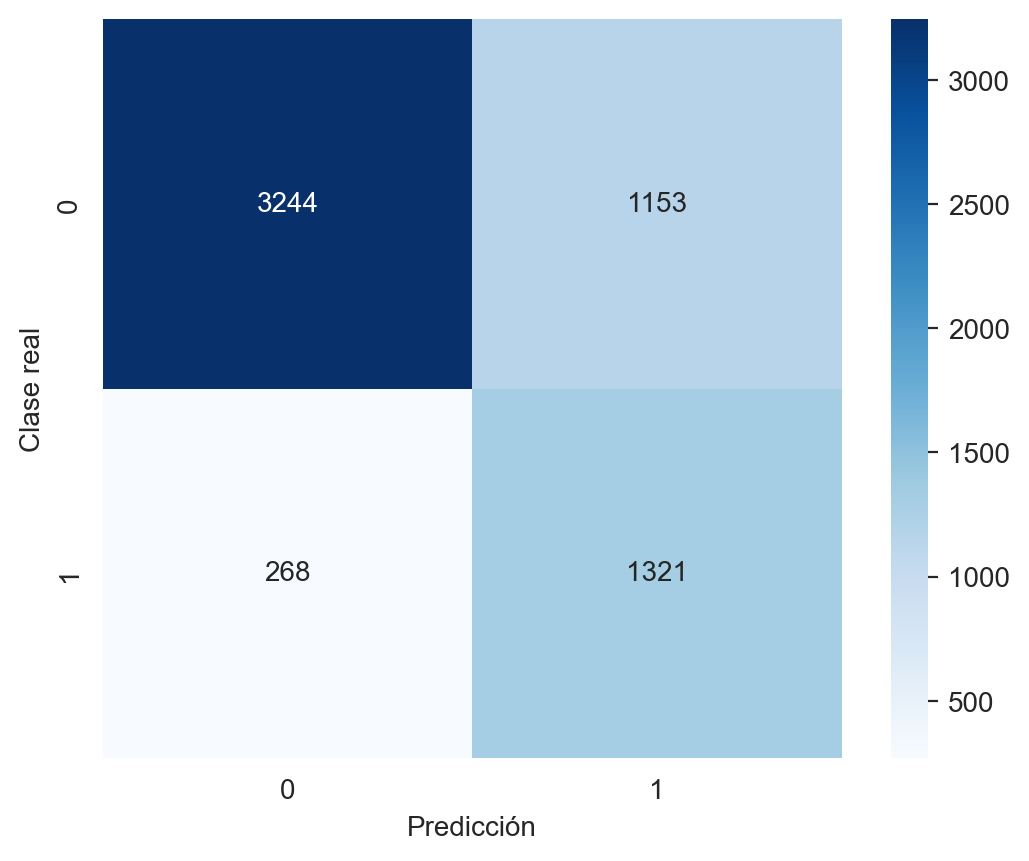

Resultados: 
	accuracy: 0.763
	recall: 0.831
	precision: 0.534
	f1_score: 0.650


In [43]:
y_pred = churn_pipe_logr.predict(X_train)

show_results(y_train, y_pred)

#### Curva Precision-Recall y selección del umbral

Se ha construido la curva Precision-Recall a partir de las probabilidades predichas por el modelo, lo que permite analizar cómo varía el rendimiento en función del umbral de decisión.

Para determinar un umbral adecuado, se ha utilizado el F1-score, que equilibra precisión y recall. El valor óptimo corresponde al punto donde esta métrica alcanza su máximo, situándose en torno a 0.54 en este caso.

No obstante, la elección del umbral debe alinearse con el objetivo del problema. En este escenario, interesa maximizar la detección de clientes que causarán baja, lo que implica priorizar el recall. Por ello, umbrales más bajos pueden ser preferibles, ya que reducen el número de falsos negativos, aunque aumenten los falsos positivos.

En un contexto real, la decisión final sobre el umbral dependería del coste asociado a cada tipo de error. Si el impacto de no detectar un cliente que abandona es alto, se justificará un enfoque orientado a maximizar el recall, incluso a costa de reducir la precisión.

Mejor umbral=0.5815, F1_score=0.6607
Umbrales considerados: 		 [0.0132 0.0132 0.0135 ... 0.9451 0.9465 0.9465]
Predicciones (valores únicos):   [0.0132 0.0132 0.0135 ... 0.9451 0.9465 0.9465]


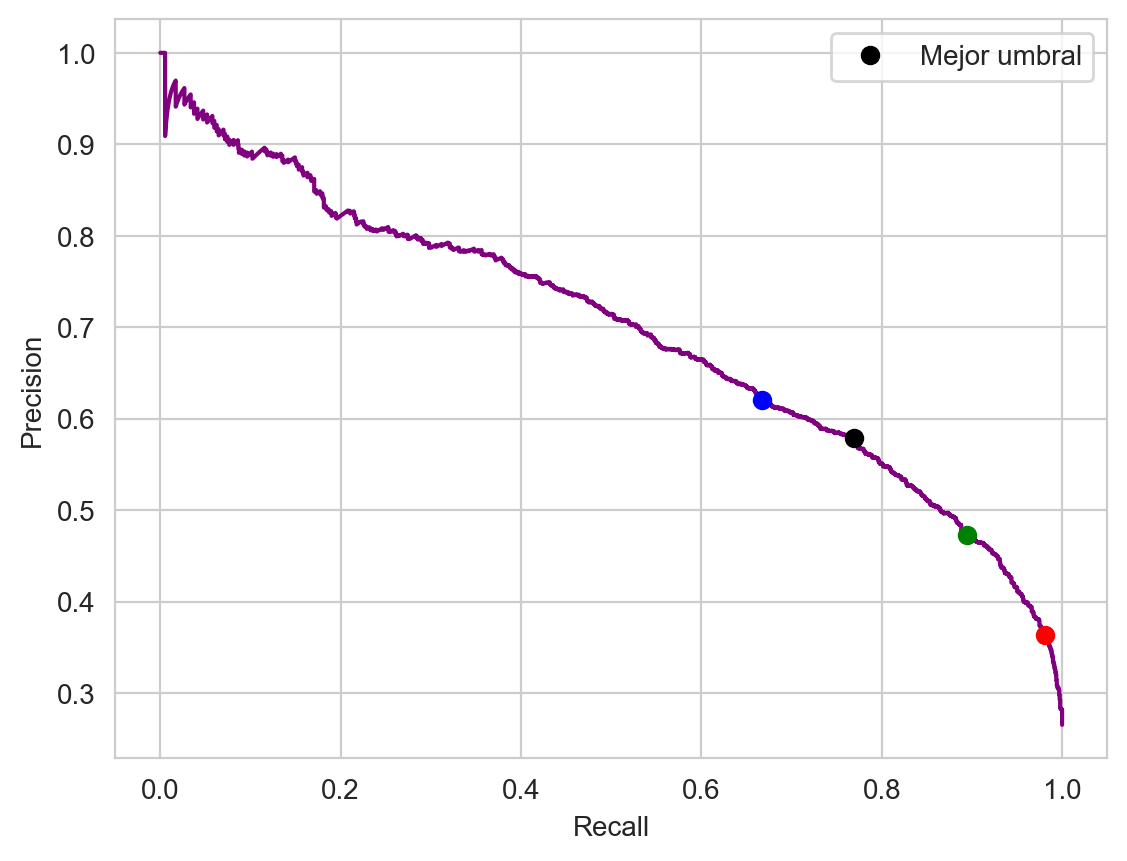

In [44]:
from sklearn.metrics import precision_recall_curve

y_prob = churn_pipe_logr.predict_proba(X)[:,1]

precision, recall, thresholds = precision_recall_curve(y, y_prob, pos_label=1)

plt.plot(recall, precision, color='purple');

# se crea un vector que almacena la métrica f1_score a partir de los vectores precision y recall
fscore = (2 * precision * recall) / (precision + recall)
# se localiza el índice que contiene el f1_score más alto
imax = np.argmax(fscore)
print('Mejor umbral=%.4f, F1_score=%.4f' % (thresholds[imax], fscore[imax]))

plt.plot(recall[2000],precision[2000], 'or'); # Umbral = 0.227, rojo
plt.plot(recall[3500],precision[3500], 'og'); # Umbral = 0.5, verde
plt.plot(recall[5000],precision[5000], 'ob'); # Umbral = 0.805, azul

plt.plot(recall[imax], precision[imax], 'ok', label='Mejor umbral');
plt.legend()

plt.xlabel('Recall')
plt.ylabel('Precision');

print("Umbrales considerados: \t\t", np.round(thresholds,4))
print("Predicciones (valores únicos):  ", np.round(np.unique(y_prob),4))

#### Árbol de decisión

Con el objetivo de comparar el rendimiento del modelo base, se entrena un clasificador basado en árboles de decisión utilizando el mismo flujo de preprocesamiento definido previamente.

Se emplea validación cruzada mediante GridSearchCV para identificar la mejor combinación de hiperparámetros, utilizando como métrica principal el recall, dado que el objetivo del problema es minimizar los falsos negativos.

#### Entrenamiento y selección de hiperparámetros

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_model = DecisionTreeClassifier()

churn_pipe_tree = Pipeline(steps=[
    ('prep', churn_trans),
    ('clas', dt_model)
])

parameters = {
    'prep__num__imputer__strategy': ['mean', 'median'],
     'clas__max_depth' : [3, 5, 7],
    #'clas__max_depth': [None, 3, 5, 7, 9],
    'clas__min_samples_leaf': [10, 20, 50],
    'clas__class_weight': [None, 'balanced']
}

GS = GridSearchCV(
    churn_pipe_tree,
    param_grid=parameters,
    scoring='recall',
    refit=True,
    cv=5
)

GS.fit(X_train, y_train)

churn_pipe_tree = GS.best_estimator_

print("Mejor configuración de parámetros:", GS.best_params_)

Mejor configuración de parámetros: {'clas__class_weight': 'balanced', 'clas__max_depth': 7, 'clas__min_samples_leaf': 50, 'prep__num__imputer__strategy': 'mean'}


#### Máquina de soporte vectorial (SVM)

Se entrena un modelo basado en máquinas de soporte vectorial utilizando el mismo pipeline de preprocesamiento, con el objetivo de comparar su rendimiento frente a los modelos anteriores.

Se realiza una búsqueda de hiperparámetros mediante validación cruzada, optimizando la métrica recall para mantener el enfoque en la detección de clientes con riesgo de abandono.

#### Entrenamiento y selección de hiperparámetros

In [46]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)
# svm_model = SVC(probability=False) #se puede poner así para no ralentizar la ejecución

churn_pipe_svc = Pipeline(steps=[
    ('prep', churn_trans),
    ('clas', svm_model)
])

parameters = {
    'prep__num__imputer__strategy': ['mean', 'median'],
    'clas__C': [0.1, 1, 100],
    'clas__kernel': ['linear', 'rbf']
}

GS = GridSearchCV(
    churn_pipe_svc,
    param_grid=parameters,
    scoring='recall',
    refit=True,
    cv=5
)

GS.fit(X_train, y_train)

churn_pipe_svc = GS.best_estimator_

print("Mejor configuración de parámetros:", GS.best_params_)

Mejor configuración de parámetros: {'clas__C': 100, 'clas__kernel': 'linear', 'prep__num__imputer__strategy': 'mean'}


## 6. Resultados de los modelos con nuevos datos

Una vez definido el modelo final y el flujo completo de trabajo, se procede a evaluar su comportamiento sobre un nuevo conjunto de datos no utilizado durante el entrenamiento (`df_churn_new`).

Para ello, se aplica el mismo proceso de preparación mediante `preprocess_data`, garantizando la consistencia con los datos de entrenamiento. Posteriormente, se generan las predicciones utilizando los pipelines entrenados (`churn_pipe_logr`, `churn_pipe_tree` y `churn_pipe_svc`).

Dado que la variable objetivo fue transformada fuera del pipeline, se realiza previamente su conversión a formato binario.

Este procedimiento permite obtener una estimación realista del rendimiento del modelo en un entorno productivo.

#### 6.1 Regresión logística con nuevos datos

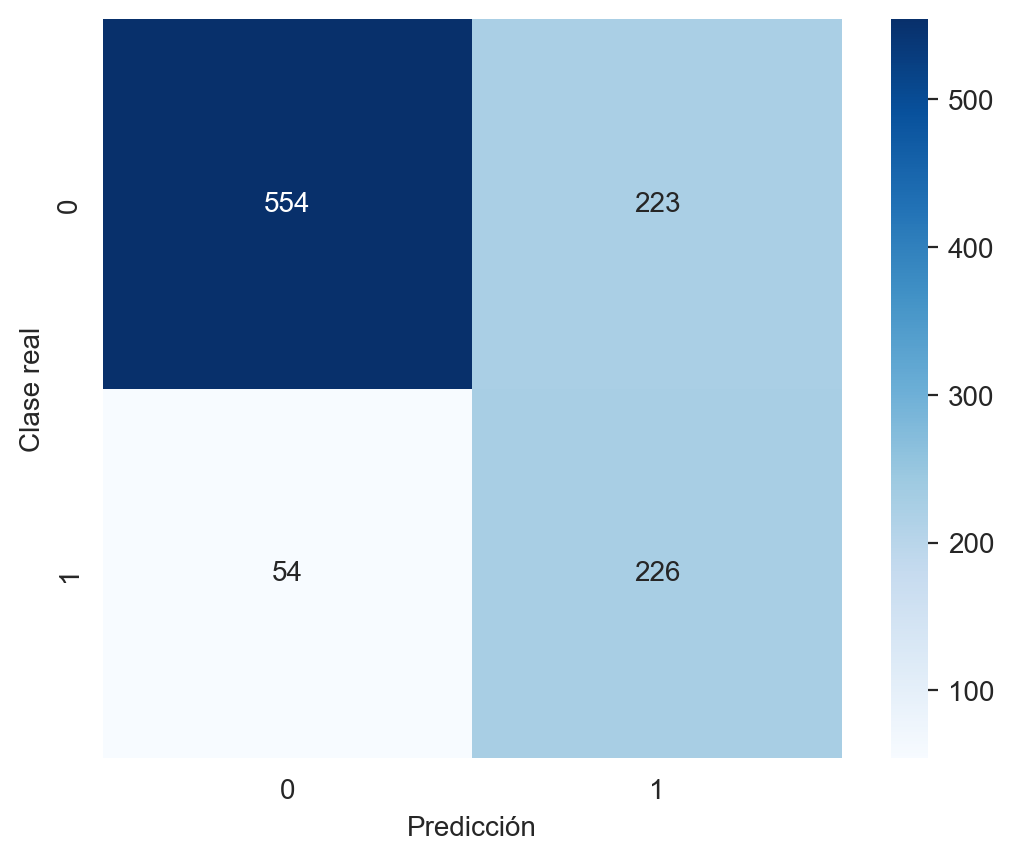

Resultados: 
	accuracy: 0.738
	recall: 0.807
	precision: 0.503
	f1_score: 0.620


In [47]:
# Predicción
y_pred_new = churn_pipe_logr.predict(X_test)

# Evaluación
show_results(y_test, y_pred_new)

Los resultados obtenidos reflejan la capacidad de generalización del modelo, al evaluarse sobre datos completamente nuevos. Esto permite validar su utilidad real para la detección de clientes con riesgo de abandono.

#### 6.2 Árbol de decisión con nuevos datos

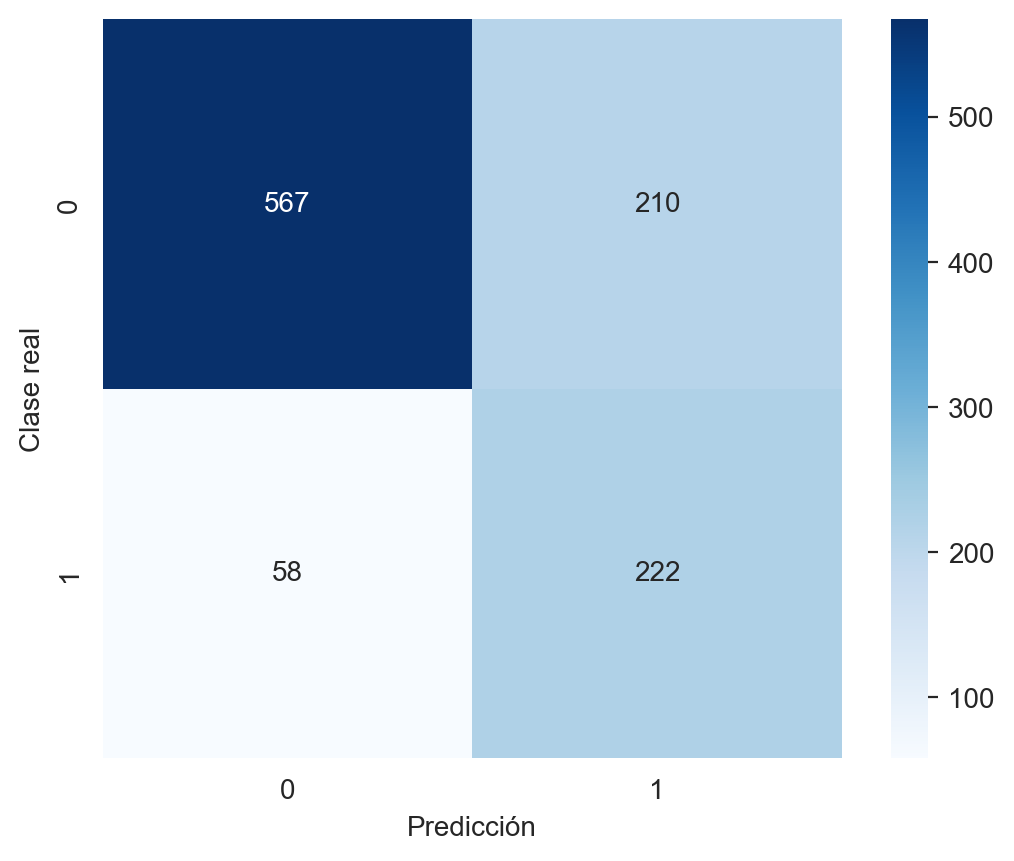

Resultados: 
	accuracy: 0.746
	recall: 0.793
	precision: 0.514
	f1_score: 0.624


In [48]:
y_pred_tree = churn_pipe_tree.predict(X_test)

show_results(y_test, y_pred_tree)

#### Curva Precision-Recall

Se analiza la relación entre precisión y recall para distintos umbrales de decisión, lo que permite evaluar el comportamiento del modelo en diferentes escenarios operativos.

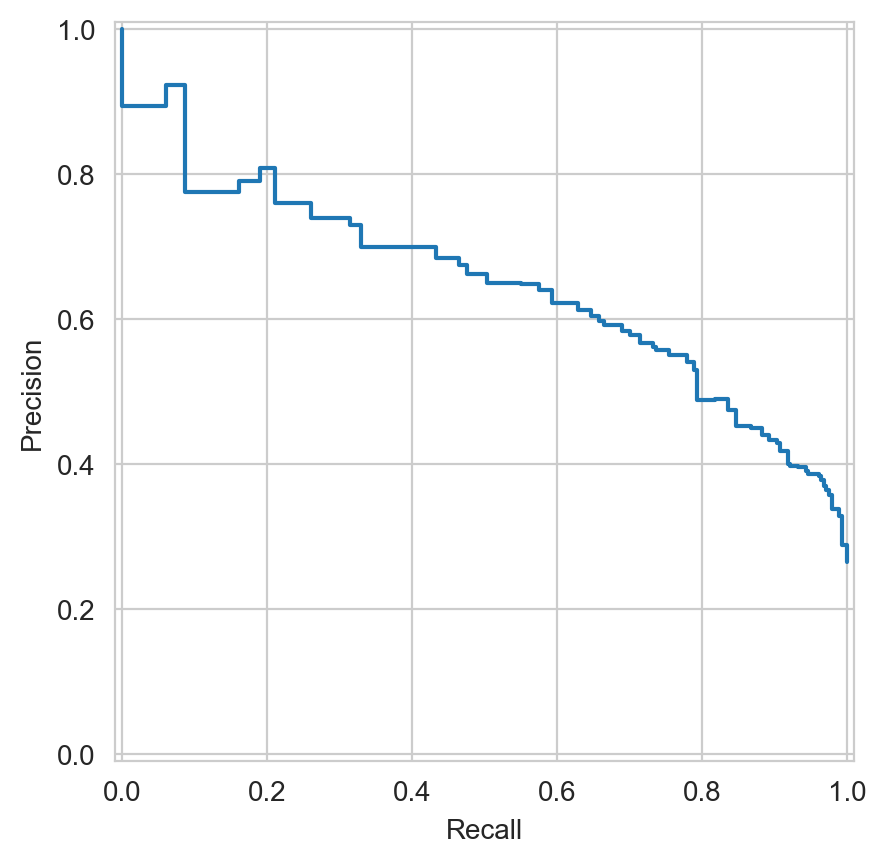

In [49]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

y_prob_tree = churn_pipe_tree.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob_tree)

PrecisionRecallDisplay(precision=precision, recall=recall).plot()

#### Ajuste del umbral de decisión

Es posible incrementar la precisión del modelo elevando el umbral de clasificación. Por ejemplo, un umbral cercano a 0.8 permite alcanzar valores de precisión en torno a 0.75.

Sin embargo, este ajuste implica una reducción significativa del recall, aumentando el número de falsos negativos. En este contexto, donde el objetivo es identificar clientes con riesgo de abandono, esta estrategia no resulta adecuada.

Por tanto, se prioriza un equilibrio que favorezca un recall elevado, incluso a costa de una menor precisión.

El árbol de decisión ofrece una interpretación más sencilla que la regresión logística, aunque tiende a presentar mayor varianza y menor capacidad de generalización si no se controla adecuadamente su complejidad.

#### 6.3 SVC con nuevos datos

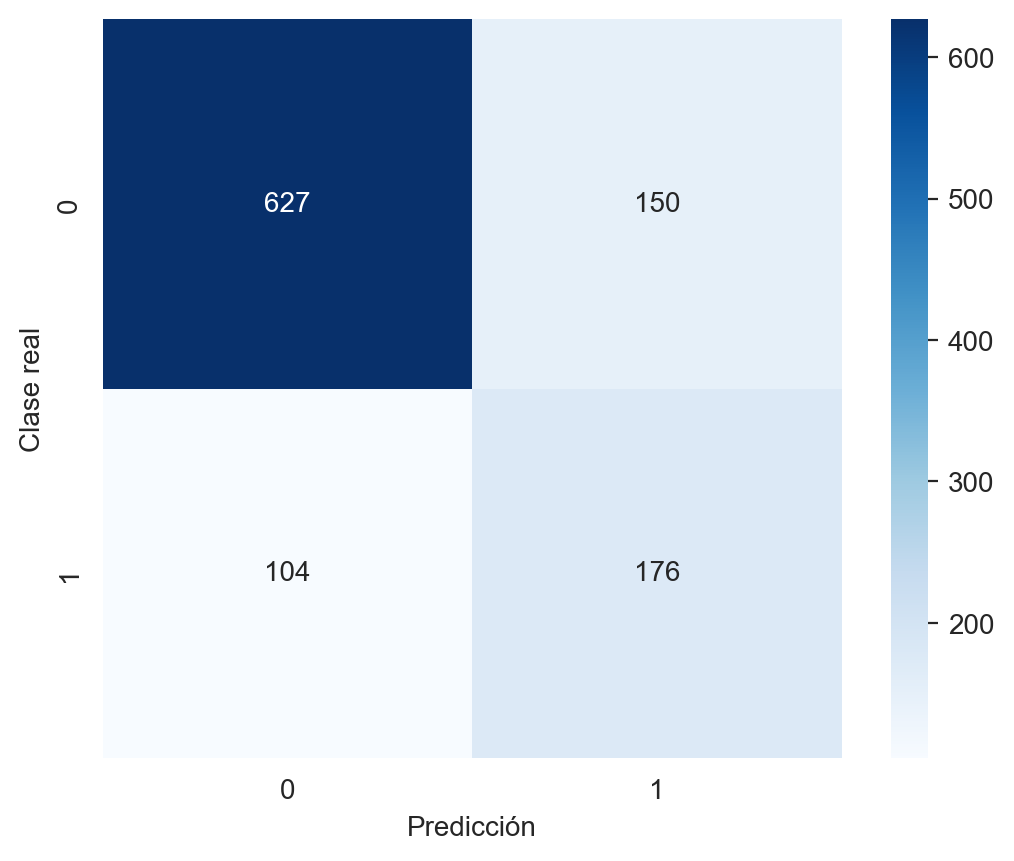

Resultados: 
	accuracy: 0.760
	recall: 0.629
	precision: 0.540
	f1_score: 0.581


In [50]:
y_pred_svc = churn_pipe_svc.predict(X_test)

show_results(y_test, y_pred_svc)

#### Curva Precision-Recall

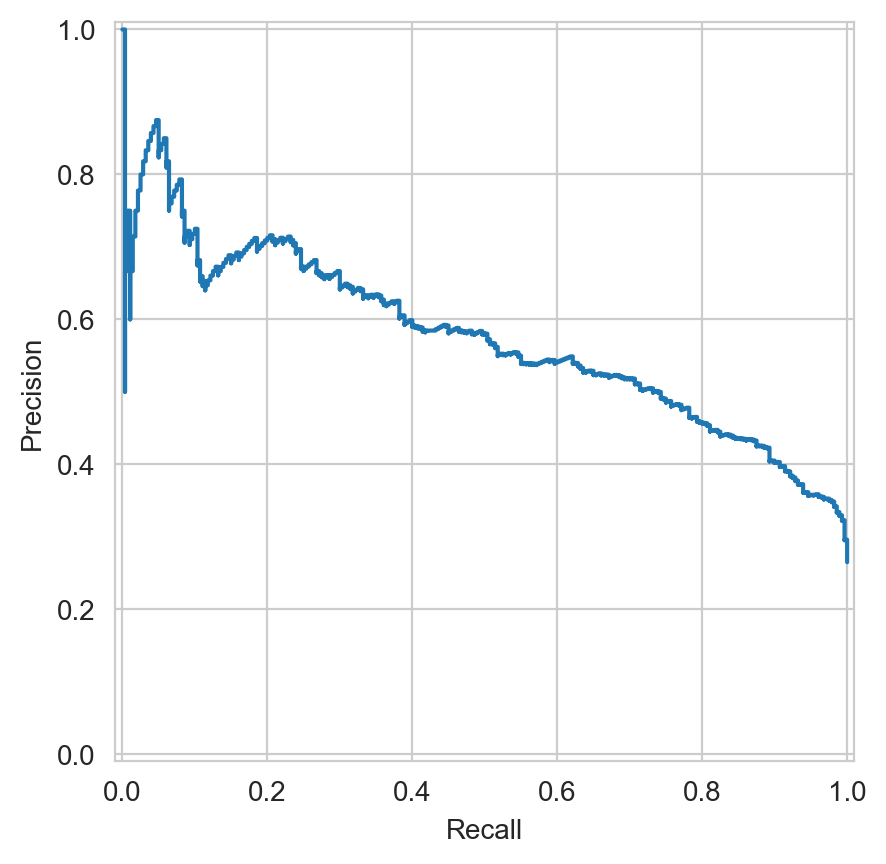

In [51]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

y_prob_svc = churn_pipe_svc.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob_svc)

PrecisionRecallDisplay(precision=precision, recall=recall).plot()

#### 6.4 Comparación de modelos

El rendimiento de los modelos depende del umbral de decisión utilizado. Para evitar este sesgo, se utiliza la curva ROC, que evalúa el comportamiento del modelo considerando todos los umbrales posibles.

El área bajo la curva (AUC) permite comparar los clasificadores de forma global, midiendo su capacidad para distinguir entre clientes que abandonan y los que no.

#### Área bajo la curva ROC (AUC)

Para completar la comparación entre modelos, se calcula el área bajo la curva ROC (AUC), que proporciona una medida global de la capacidad de discriminación independientemente del umbral de decisión.

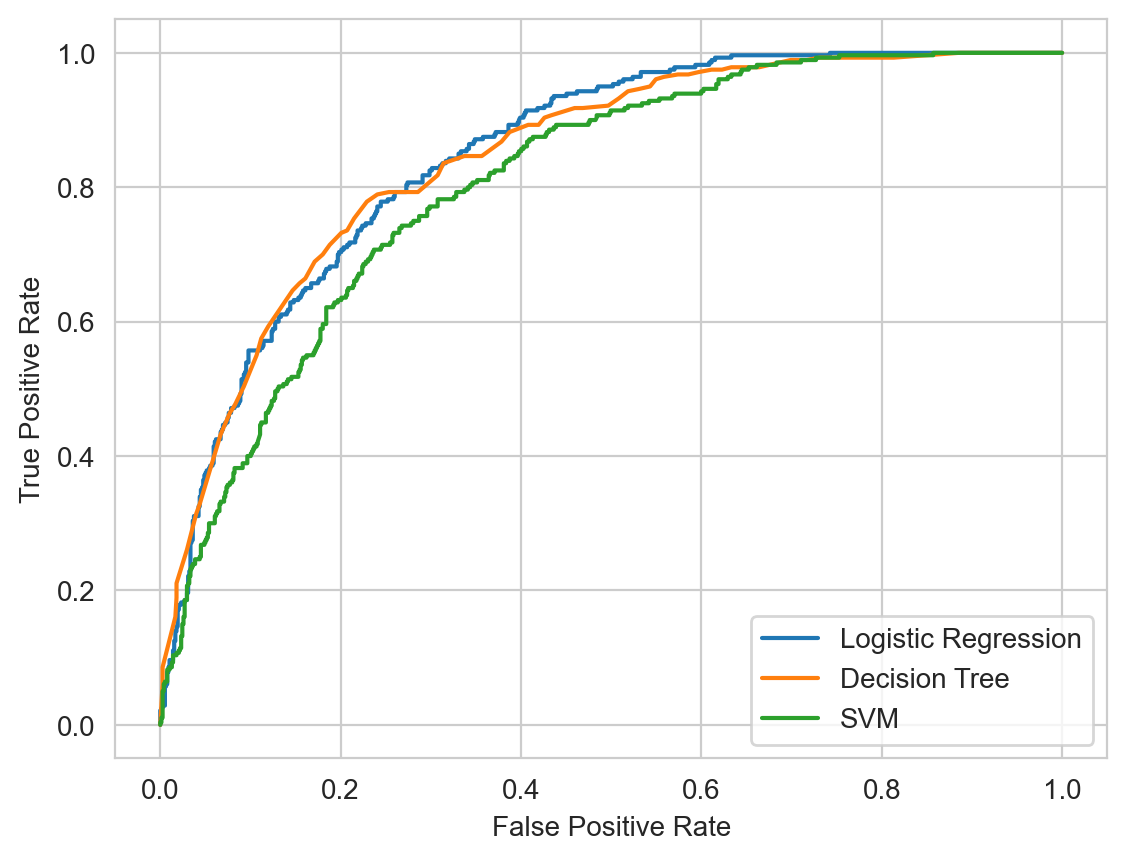

In [52]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob_logr = churn_pipe_logr.predict_proba(X_test)[:,1]
y_prob_tree = churn_pipe_tree.predict_proba(X_test)[:,1]
y_prob_svc = churn_pipe_svc.predict_proba(X_test)[:,1]

fpr_logr, tpr_logr, _ = roc_curve(y_test, y_prob_logr)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)

plt.plot(fpr_logr, tpr_logr, label='Logistic Regression')
plt.plot(fpr_tree, tpr_tree, label='Decision Tree')
plt.plot(fpr_svc, tpr_svc, label='SVM')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [53]:
from sklearn.metrics import roc_auc_score

print("Regresión logística:", roc_auc_score(y_test, y_prob_logr))
print("Árbol de decisión:", roc_auc_score(y_test, y_prob_tree))
print("Máquina de soporte vectorial:", roc_auc_score(y_test, y_prob_svc))

Regresión logística: 0.8478373781945211
Árbol de decisión: 0.8446727339584481
Máquina de soporte vectorial: 0.80744851994852


#### 6.5 Conclusión final.

Los tres modelos presentan valores de AUC similares, en torno a 0.85, lo que indica una capacidad comparable para discriminar entre clientes que abandonan y los que no a nivel global.

No obstante, al analizar el rendimiento con un umbral de decisión concreto, se observan diferencias relevantes entre los modelos. En particular, la regresión logística alcanza un recall significativamente superior, lo que le permite identificar un mayor número de clientes en riesgo de abandono.

Por el contrario, el árbol de decisión y la máquina de soporte vectorial, aunque presentan una precisión mayor, reducen considerablemente su capacidad de detección, generando un mayor número de falsos negativos.

Dado que el objetivo del problema es minimizar la pérdida de clientes, se prioriza el recall frente a otras métricas. En este contexto, la regresión logística se posiciona como la alternativa más adecuada, a pesar de que las diferencias en AUC entre modelos no sean significativas.